In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, BaggingClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.ensemble import StackingRegressor, StackingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    mean_squared_error, mean_absolute_error, r2_score, classification_report,
)
import optuna
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Загрузка предобработанных датасетов

In [ ]:
data_reg= pd.read_csv('../../data/energy_task_treated.csv', sep=',', encoding='utf-8')
data_reg.head(10)

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,month,day,hour,minute
0,60,0,22.0,44.0,21,44,20,46,21,47,...,6,736,87,7.0,40.0,4.0,1,11,11,0
1,60,0,22.0,44.0,21,44,20,46,21,46,...,6,736,88,7.0,37.0,4.0,1,11,11,10
2,50,0,22.0,44.0,21,44,20,46,21,46,...,6,736,89,7.0,34.0,4.0,1,11,11,20
3,70,0,22.0,44.0,21,44,20,46,21,47,...,6,737,90,6.0,31.0,4.0,1,11,11,30
4,60,0,22.0,44.0,21,44,20,46,21,47,...,6,737,90,6.0,28.0,4.0,1,11,11,40
5,40,0,21.0,44.0,21,44,20,46,21,47,...,5,737,91,6.0,25.0,4.0,1,11,11,50
6,40,0,21.0,45.0,21,44,20,46,21,47,...,5,737,92,6.0,22.0,4.0,1,12,0,0
7,30,0,21.0,45.0,21,44,20,46,21,47,...,5,737,92,6.0,25.0,4.0,1,12,0,10
8,40,0,21.0,45.0,21,44,20,46,20,47,...,5,737,92,6.0,28.0,4.0,1,12,0,20
9,50,0,21.0,45.0,21,44,20,46,20,47,...,5,737,92,6.0,31.0,4.0,1,12,0,30


In [ ]:
data_cls= pd.read_csv('../../data/csgo_task_treated.csv', sep=',', encoding='utf-8')
data_cls.head(10)

,ct_score,t_score,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,t_money,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,map_binary,time_left_sec,time_left_ms
0,0,0,0,500,500,0,0,4000,4000,0,0,0,5,5,64,175,0
1,0,0,0,500,500,400,300,600,650,0,0,1,5,5,64,156,30
2,0,0,0,391,400,294,200,750,500,0,0,1,4,4,64,96,30
3,0,0,0,391,400,294,200,750,500,0,0,1,4,4,64,76,30
4,1,0,0,500,500,192,0,18350,10750,0,0,1,5,5,64,174,970
5,1,0,0,500,500,500,0,1750,10550,5,0,1,5,5,64,114,970
6,1,0,0,295,111,296,0,1700,5000,3,0,0,3,2,64,94,970
7,1,0,0,295,111,296,0,1700,5000,3,0,0,3,2,64,74,970
8,1,0,0,249,89,269,0,2300,2950,3,0,0,3,1,64,54,970
9,2,0,0,500,500,196,0,19800,23450,2,0,0,5,5,64,174,970


# Выделяем целевой и входные признаки

In [4]:
y_reg = data_reg["Appliances"]
X_reg = data_reg.drop(["Appliances"], axis=1)

In [5]:
y_cls = data_cls["bomb_planted"]
X_cls = data_cls.drop(["bomb_planted"], axis=1)

# Разбиваем данные на обучающую и тестовую выборки

In [6]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [7]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls )

# Функции для подбора гиперпараметров с Optuna

In [93]:
def optimize_tree_classifier(X, y, n_trials=30):
    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 2, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
            'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
            'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        }
        model = DecisionTreeClassifier(**params, random_state=42)
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
        return scores.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params

In [ ]:
def optimize_tree_regressor(X, y, n_trials=30):
    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 2, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
            'criterion': trial.suggest_categorical('criterion', ['squared_error', 'friedman_mse']),
            'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        }
        model = DecisionTreeRegressor(**params, random_state=42)
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
        return -scores.mean()  
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params

In [10]:
def optimize_gb_classifier(X, y, n_trials=40):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 200),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        }
        model = GradientBoostingClassifier(**params, random_state=42)
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        return scores.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value  # Возвращаем кортеж

In [11]:
def optimize_gb_regressor(X, y, n_trials=40):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 200),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        }
        model = GradientBoostingRegressor(**params, random_state=42)
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
        return -scores.mean()
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value  # Возвращаем кортеж

In [12]:
def optimize_bagging_classifier(X, y, n_trials=30):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 100),
            'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
            'max_features': trial.suggest_float('max_features', 0.5, 1.0),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'bootstrap_features': trial.suggest_categorical('bootstrap_features', [True, False]),
        }
        base_estimator = DecisionTreeClassifier(
            max_depth=trial.suggest_int('base_max_depth', 3, 10),
            min_samples_split=trial.suggest_int('base_min_samples_split', 2, 10),
            random_state=42
        )
        model = BaggingClassifier(estimator=base_estimator, **params, random_state=42, n_jobs=-1)
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
        return scores.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value  # Возвращаем кортеж

In [13]:
def optimize_bagging_regressor(X, y, n_trials=30):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 100),
            'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
            'max_features': trial.suggest_float('max_features', 0.5, 1.0),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'bootstrap_features': trial.suggest_categorical('bootstrap_features', [True, False]),
        }
        base_estimator = DecisionTreeRegressor(
            max_depth=trial.suggest_int('base_max_depth', 3, 10),
            min_samples_split=trial.suggest_int('base_min_samples_split', 2, 10),
            random_state=42
        )
        model = BaggingRegressor(estimator=base_estimator, **params, random_state=42, n_jobs=-1)
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
        return -scores.mean()
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value  # Возвращаем кортеж

In [14]:
def optimize_stacking_classifier(X, y, n_trials=25):
    def objective(trial):
        dt_params = {
            'max_depth': trial.suggest_int('dt_max_depth', 3, 12),
            'min_samples_split': trial.suggest_int('dt_min_samples_split', 2, 10),
            'criterion': trial.suggest_categorical('dt_criterion', ['gini', 'entropy']),
        }
        gb_params = {
            'n_estimators': trial.suggest_int('gb_n_estimators', 50, 150),
            'max_depth': trial.suggest_int('gb_max_depth', 3, 8),
            'learning_rate': trial.suggest_float('gb_learning_rate', 0.01, 0.3, log=True),
        }
        bag_params = {
            'n_estimators': trial.suggest_int('bag_n_estimators', 10, 50),
        }
        
        dt = DecisionTreeClassifier(**dt_params, random_state=42)
        gb = GradientBoostingClassifier(**gb_params, random_state=42)
        bagging = BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=5),
            n_estimators=bag_params['n_estimators'],
            random_state=42
        )
        
        final_estimator = LogisticRegression(
            C=trial.suggest_float('logreg_C', 0.01, 10, log=True),
            penalty=trial.suggest_categorical('logreg_penalty', ['l1', 'l2']),
            solver='liblinear'
        )
        
        model = StackingClassifier(
            estimators=[('dt', dt), ('gb', gb), ('bagging', bagging)],
            final_estimator=final_estimator,
            cv=trial.suggest_categorical('stack_cv', [3, 5])
        )
        
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        return scores.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value  # Возвращаем кортеж

In [15]:
def optimize_stacking_regressor(X, y, n_trials=25):
    def objective(trial):
        dt_params = {
            'max_depth': trial.suggest_int('dt_max_depth', 3, 12),
            'min_samples_split': trial.suggest_int('dt_min_samples_split', 2, 10),
            'criterion': trial.suggest_categorical('dt_criterion', ['squared_error', 'friedman_mse']),
        }
        gb_params = {
            'n_estimators': trial.suggest_int('gb_n_estimators', 50, 150),
            'max_depth': trial.suggest_int('gb_max_depth', 3, 8),
            'learning_rate': trial.suggest_float('gb_learning_rate', 0.01, 0.3, log=True),
        }
        bag_params = {
            'n_estimators': trial.suggest_int('bag_n_estimators', 10, 50),
        }
        
        dt = DecisionTreeRegressor(**dt_params, random_state=42)
        gb = GradientBoostingRegressor(**gb_params, random_state=42)
        bagging = BaggingRegressor(
            estimator=DecisionTreeRegressor(max_depth=5),
            n_estimators=bag_params['n_estimators'],
            random_state=42
        )
        
        model = StackingRegressor(
            estimators=[('dt', dt), ('gb', gb), ('bagging', bagging)],
            final_estimator=LinearRegression(),
            cv=trial.suggest_categorical('stack_cv', [3, 5])
        )
        
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
        return -scores.mean()
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value  # Возвращаем кортеж

In [ ]:
best_tree_cls_params = optimize_tree_classifier(X_train_cls, y_train_cls)
print("Best params for DecisionTreeClassifier:", best_tree_cls_params)
dt_cls = DecisionTreeClassifier(
    **best_tree_cls_params, 
    random_state=42,
    class_weight='balanced' 
)
dt_cls.fit(X_train_cls, y_train_cls)

[I 2026-04-02 11:51:03,529] A new study created in memory with name: no-name-a00c7a76-8aeb-4096-b6d3-0deb42c4b69b


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-02 11:51:03,913] Trial 0 finished with value: 0.9692811395105526 and parameters: {'max_depth': 19, 'min_samples_split': 13, 'min_samples_leaf': 15, 'criterion': 'entropy', 'max_features': 0.329522497866101}. Best is trial 0 with value: 0.9692811395105526.
[I 2026-04-02 11:51:04,514] Trial 1 finished with value: 0.9783532720559235 and parameters: {'max_depth': 9, 'min_samples_split': 17, 'min_samples_leaf': 13, 'criterion': 'gini', 'max_features': 0.9749035716277672}. Best is trial 1 with value: 0.9783532720559235.
[I 2026-04-02 11:51:04,792] Trial 2 finished with value: 0.9665712775058738 and parameters: {'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 17, 'criterion': 'entropy', 'max_features': 0.6876737713033667}. Best is trial 1 with value: 0.9783532720559235.
[I 2026-04-02 11:51:05,042] Trial 3 finished with value: 0.9628545809673188 and parameters: {'max_depth': 10, 'min_samples_split': 14, 'min_samples_leaf': 3, 'criterion': 'gini', 'max_features': 0.16946

DecisionTreeClassifier(class_weight='balanced', max_depth=13,
                       max_features=0.907454586687318, min_samples_leaf=13,
                       min_samples_split=7, random_state=42)

In [95]:
y_pred_cls = dt_cls.predict(X_test_cls)

In [96]:
best_tree_reg_params = optimize_tree_regressor(X_train_reg, y_train_reg)
print("Best params for DecisionTreeRegressor:", best_tree_reg_params)
dt_reg = DecisionTreeRegressor(**best_tree_reg_params, random_state=42)
dt_reg.fit(X_train_reg, y_train_reg)

[I 2026-04-02 11:51:54,649] A new study created in memory with name: no-name-7c5e8b5f-6619-4cb6-8a7f-e5e8f474acbb


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-02 11:51:54,690] Trial 0 finished with value: 115.1501163192911 and parameters: {'max_depth': 2, 'min_samples_split': 4, 'min_samples_leaf': 5, 'criterion': 'squared_error', 'max_features': 0.6624138462490227}. Best is trial 0 with value: 115.1501163192911.
[I 2026-04-02 11:51:54,744] Trial 1 finished with value: 109.19969276233401 and parameters: {'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 12, 'criterion': 'friedman_mse', 'max_features': 0.3969289675104065}. Best is trial 1 with value: 109.19969276233401.
[I 2026-04-02 11:51:54,776] Trial 2 finished with value: 110.37994508783167 and parameters: {'max_depth': 14, 'min_samples_split': 11, 'min_samples_leaf': 11, 'criterion': 'friedman_mse', 'max_features': 0.14793904603769586}. Best is trial 1 with value: 109.19969276233401.
[I 2026-04-02 11:51:54,839] Trial 3 finished with value: 116.37934819941836 and parameters: {'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 6, 'criterion': 'squared_error

DecisionTreeRegressor(criterion='friedman_mse', max_depth=6,
                      max_features=0.7860044139088536, min_samples_leaf=16,
                      min_samples_split=13, random_state=42)

In [97]:
y_pred_reg = dt_reg.predict(X_test_reg)

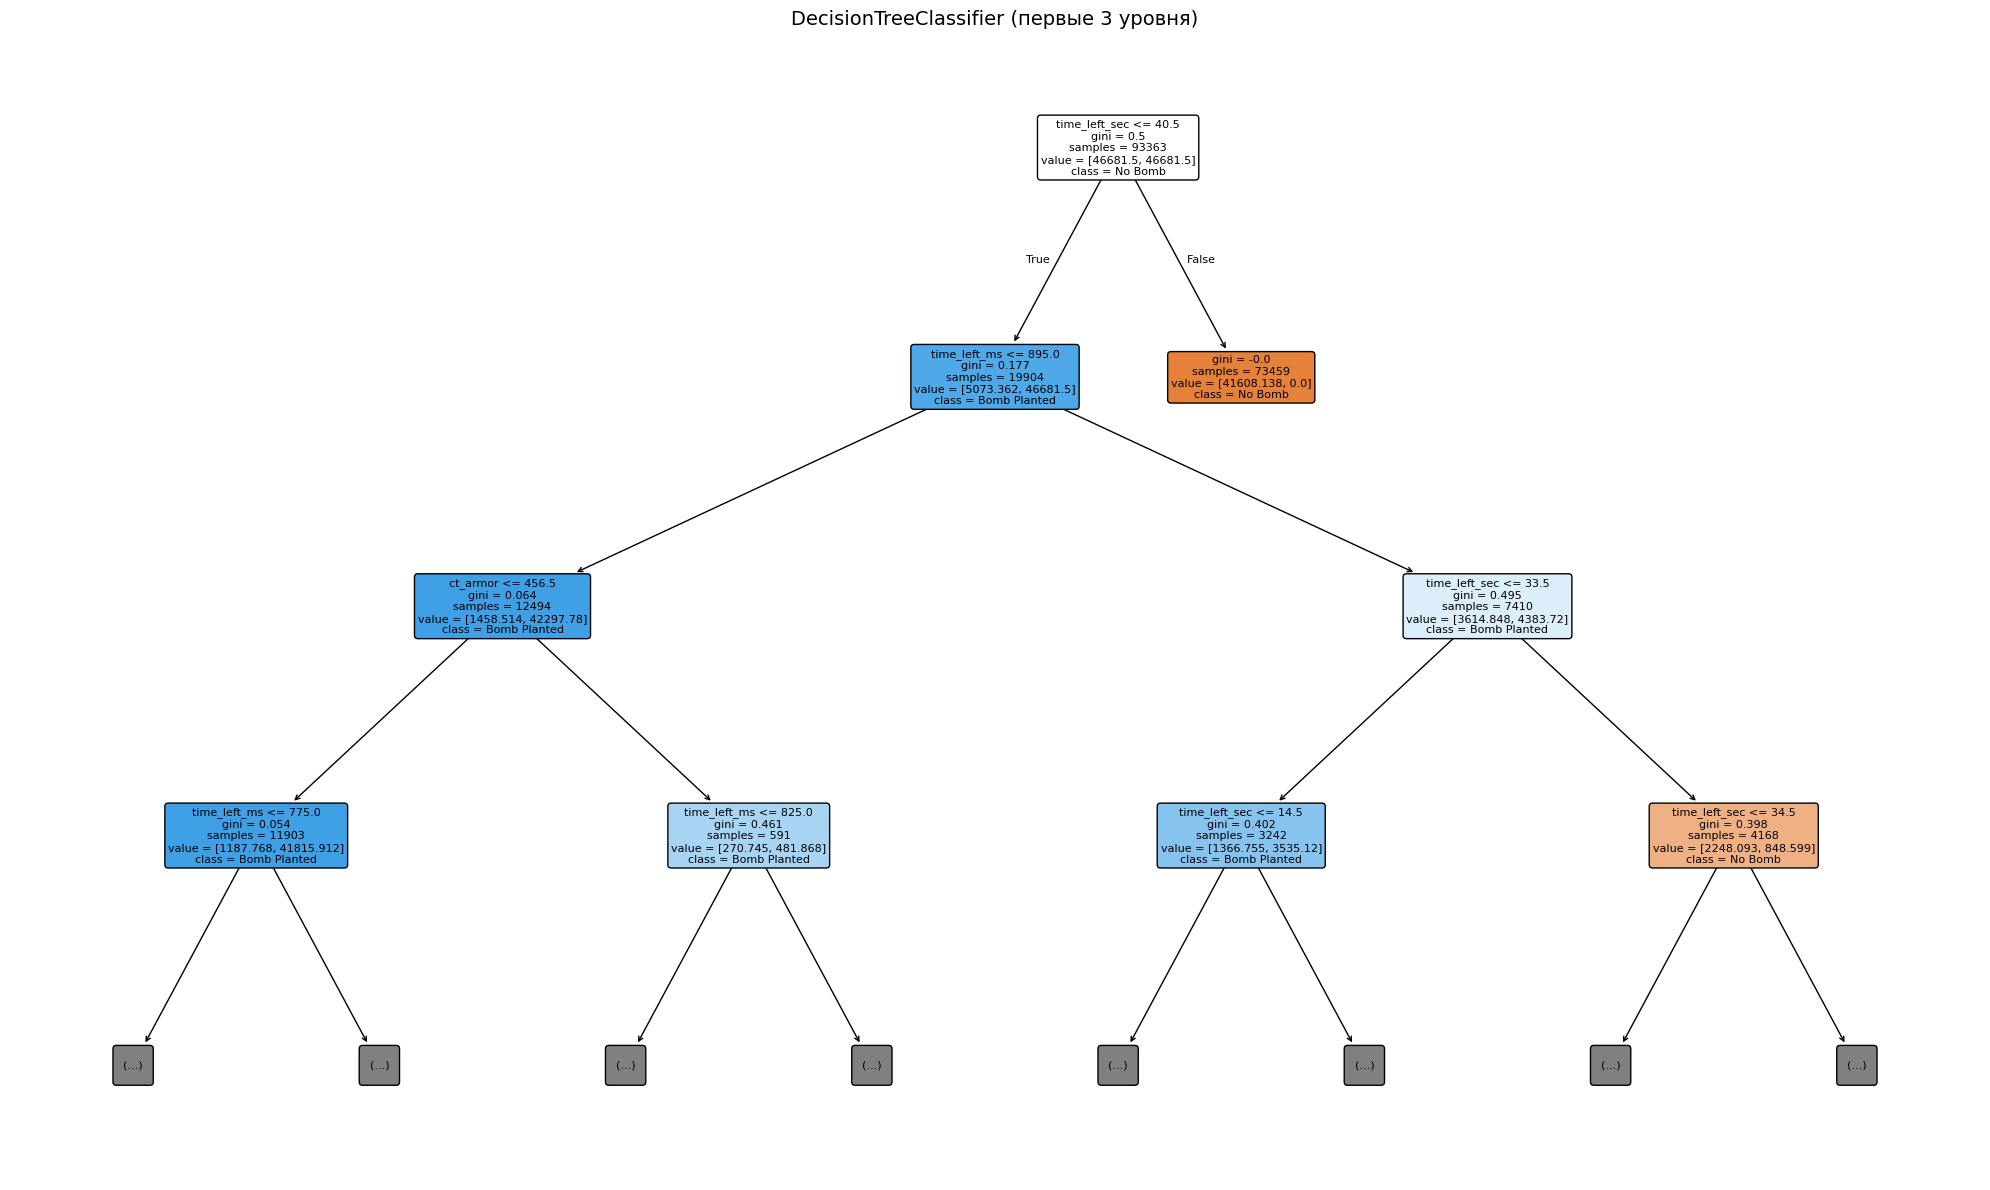

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))
plot_tree(
    dt_cls,
    feature_names=X_train_cls.columns.tolist() if hasattr(X_train_cls, 'columns') else None,
    class_names=['No Bomb', 'Bomb Planted'],
    filled=True,                
    rounded=True,                
    fontsize=8,
    max_depth=3                 
)
plt.title("DecisionTreeClassifier (первые 3 уровня)", fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_classifier.png', dpi=150, bbox_inches='tight')
plt.show()

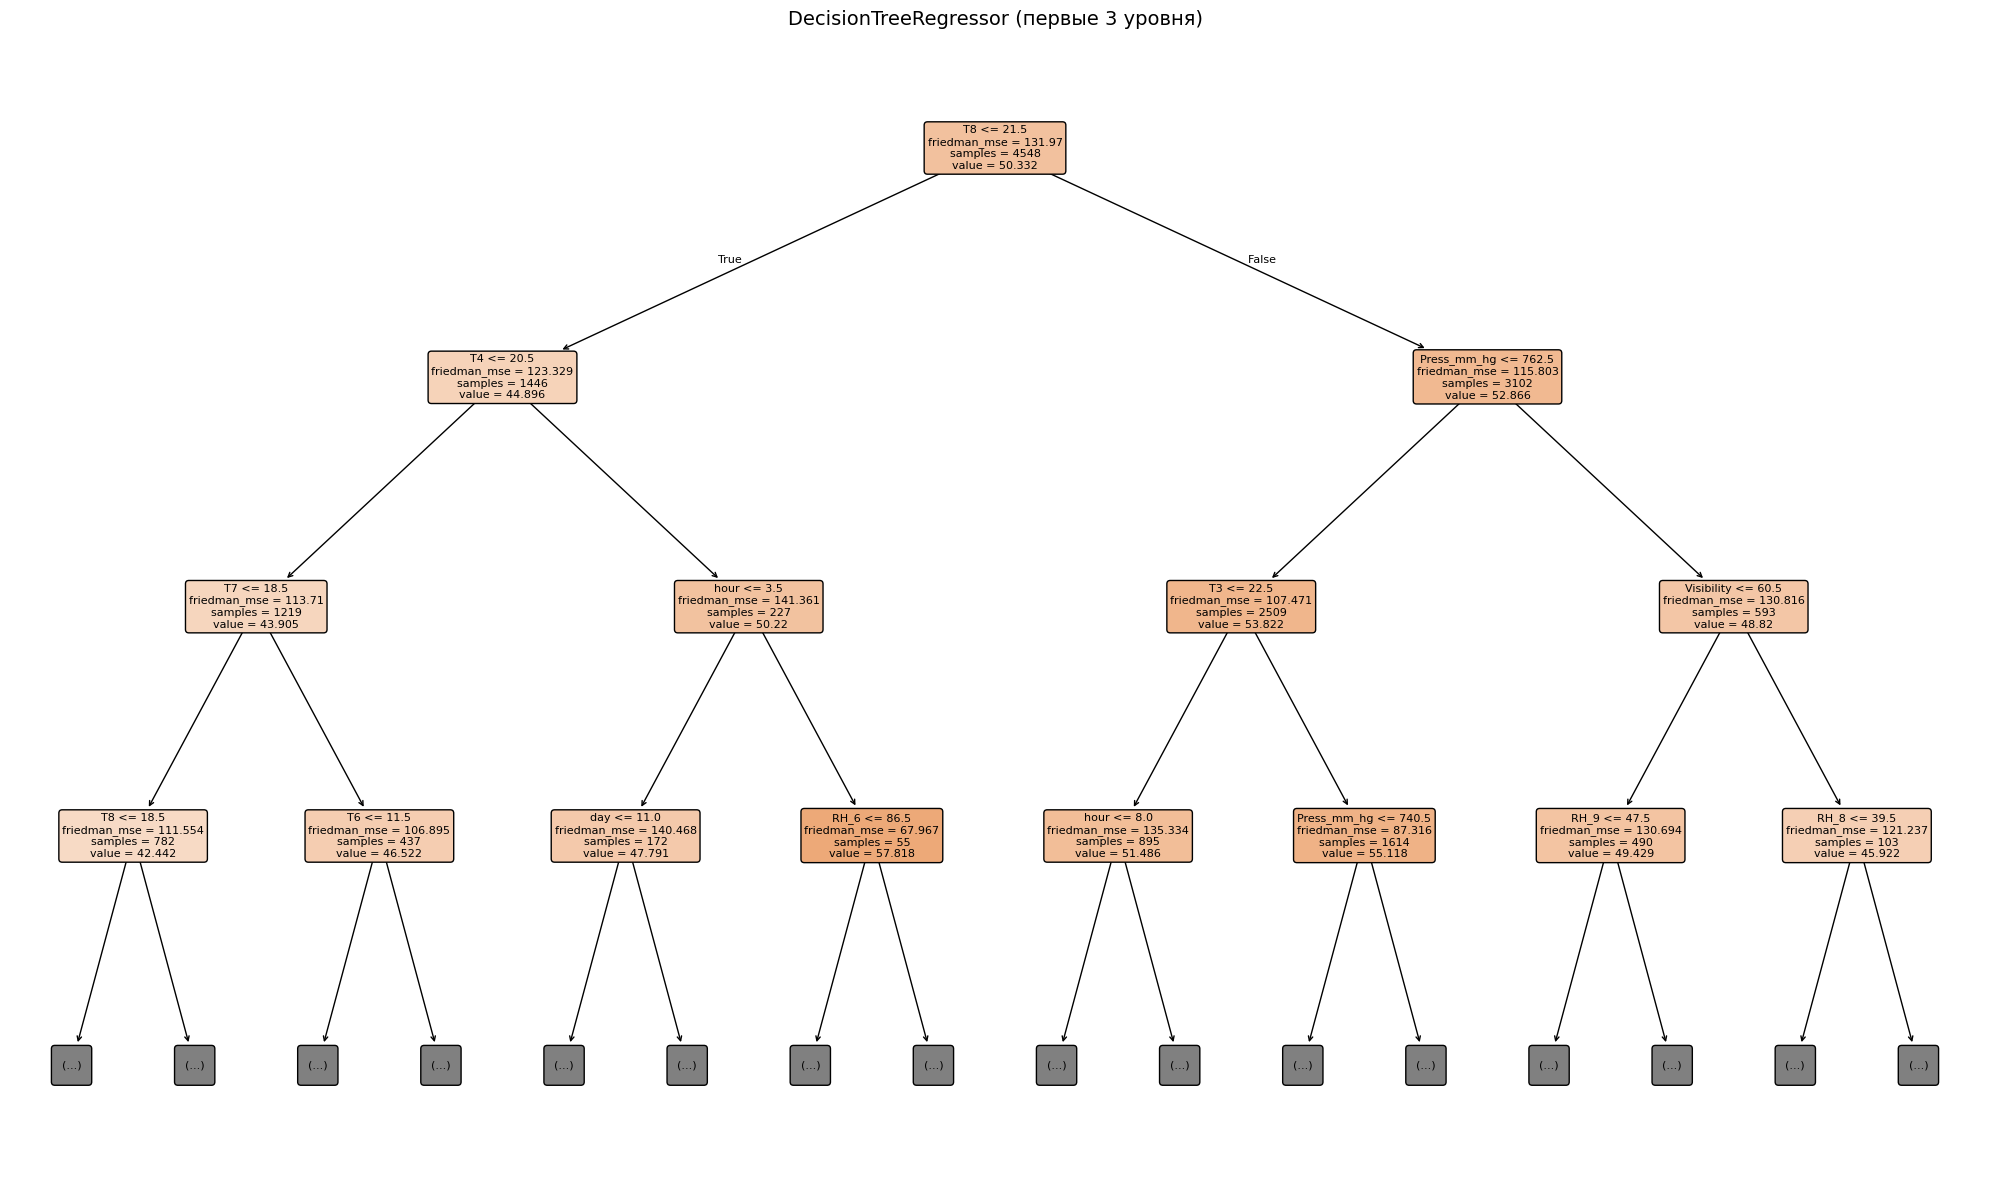

In [ ]:
plt.figure(figsize=(20, 12))
plot_tree(
    dt_reg,                   
    feature_names=X_train_reg.columns.tolist() if hasattr(X_train_reg, 'columns') else None,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("DecisionTreeRegressor (первые 3 уровня)", fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_regressor.png', dpi=150, bbox_inches='tight')
plt.show()

In [98]:
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape =np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

In [99]:
results = []
name='DecisionTreeRegressor'
metrics = calculate_metrics(y_test_reg, y_pred_reg,name)
results.append({'Модель': name, **metrics})

In [100]:
print(f"\n{'Модель':<25} {'R²':<10} {'MAE':<10} {'MSE':<12} {'RMSE':<10} {'MAPE':<10}")
print("-" * 90)
for item in results:
    print(f"{item['Модель']:<5} {item['R2']:<10.4f} {item['MAE']:<10.2f} {item['MSE']:<12.2f} {item['RMSE']:<10.2f} {item['MAPE']:<10.2f}%")


Модель                    R²         MAE        MSE          RMSE       MAPE      
------------------------------------------------------------------------------------------
DecisionTreeRegressor 0.1907     8.25       112.15       10.59      19.91     %


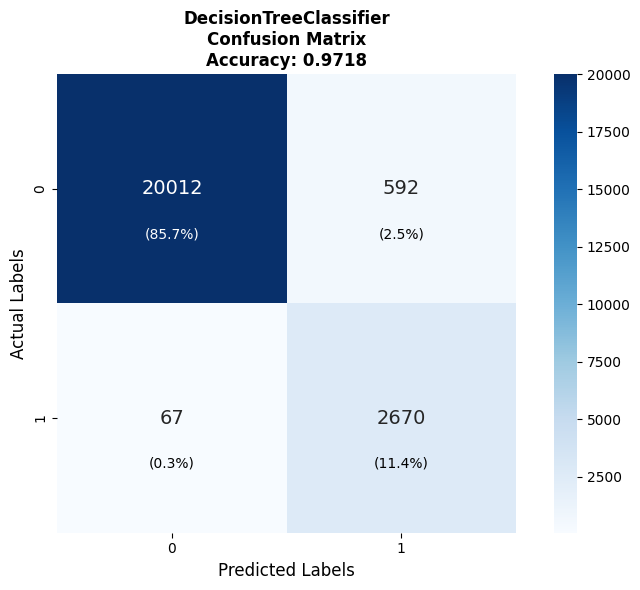


DecisionTreeClassifier
              precision    recall  f1-score   support

           0     0.9967    0.9713    0.9838     20604
           1     0.8185    0.9755    0.8901      2737

    accuracy                         0.9718     23341
   macro avg     0.9076    0.9734    0.9370     23341
weighted avg     0.9758    0.9718    0.9728     23341



In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, precision_recall_fscore_support

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

name = "DecisionTreeClassifier"

accuracy = accuracy_score(y_test_cls, y_pred_cls)

cm = confusion_matrix(y_test_cls, y_pred_cls)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            annot_kws={'size': 14}, cbar=True, square=True)
ax.set_title(f'{name}\nConfusion Matrix\nAccuracy: {accuracy:.4f}', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Labels', fontsize=12)
ax.set_ylabel('Actual Labels', fontsize=12)

total = np.sum(cm)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        percent = cm[i, j] / total * 100
        ax.text(j + 0.5, i + 0.7, f'({percent:.1f}%)', 
                ha='center', va='center', fontsize=10, 
                color='white' if cm[i, j] > total/2 else 'black')

plt.tight_layout()
plt.savefig('decision_tree_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{name}")
print("="*60)

# Получаем classification_report
report = classification_report(y_test_cls, y_pred_cls, digits=4)
print(report)


1. **Классификация** работает **отлично**:
   - Точность 97% — очень высокий результат
   - Модель хорошо находит целевое событие (Recall=0.9755)
   - Небольшое количество ложных срабатываний (594 из 20604)

2. **Регрессия** работает **плохо**:
   - R² всего 0.19 
   - Ошибка ~20% (MAPE)
   - Требуется улучшение: другие модели, новые признаки, предобработка

# Решение задачи регрессии и классификации, используя модели ансамблей из библиотеки sklearn

In [102]:
print("BaggingClassifier")
best_params, best_score = optimize_bagging_classifier(X_train_cls, y_train_cls, n_trials=25)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV accuracy: {best_score:.4f}")

# Извлекаем параметры базового дерева
base_tree_params = {}
for key, value in best_params.items():
    if key.startswith('base_'):
        base_tree_params[key.replace('base_', '')] = value

bagging_cls = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),  # балансировка в базовом дереве
    n_estimators=best_params.get('n_estimators', 50),
    random_state=42
)
bagging_cls.fit(X_train_cls, y_train_cls)

[I 2026-04-02 11:52:52,338] A new study created in memory with name: no-name-c43373d8-3676-4676-8750-1272dfe0f3f3


BaggingClassifier


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-02 11:52:57,420] Trial 0 finished with value: 0.9773250460468541 and parameters: {'n_estimators': 21, 'max_samples': 0.6658344886028501, 'max_features': 0.5229796550141996, 'bootstrap': True, 'bootstrap_features': False, 'base_max_depth': 10, 'base_min_samples_split': 10}. Best is trial 0 with value: 0.9773250460468541.
[I 2026-04-02 11:53:00,328] Trial 1 finished with value: 0.9705986058898214 and parameters: {'n_estimators': 21, 'max_samples': 0.926090854028364, 'max_features': 0.7029308164061427, 'bootstrap': False, 'bootstrap_features': False, 'base_max_depth': 4, 'base_min_samples_split': 7}. Best is trial 0 with value: 0.9773250460468541.
[I 2026-04-02 11:53:03,057] Trial 2 finished with value: 0.972676517070434 and parameters: {'n_estimators': 11, 'max_samples': 0.646252236101275, 'max_features': 0.501653204900764, 'bootstrap': False, 'bootstrap_features': True, 'base_max_depth': 8, 'base_min_samples_split': 7}. Best is trial 0 with value: 0.9773250460468541.
[I 2026-

BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                   random_state=42),
                  n_estimators=99, random_state=42)

In [103]:
print("BaggingRegressor")
best_params, best_score = optimize_bagging_regressor(X_train_reg, y_train_reg, n_trials=25)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV MSE: {best_score:.4f}")

base_tree_params_reg = {}
for key, value in best_params.items():
    if key.startswith('base_'):
        base_tree_params_reg[key.replace('base_', '')] = value

bagging_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(**base_tree_params_reg, random_state=42),
    n_estimators=best_params.get('n_estimators', 50),
    max_samples=best_params.get('max_samples', 0.8),
    max_features=best_params.get('max_features', 0.8),
    bootstrap=best_params.get('bootstrap', True),
    bootstrap_features=best_params.get('bootstrap_features', False),
    random_state=42,
    n_jobs=-1
)
bagging_reg.fit(X_train_reg, y_train_reg)

[I 2026-04-02 11:56:10,950] A new study created in memory with name: no-name-d40785a1-db46-476d-a114-d5f608b6bdcf


BaggingRegressor


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-02 11:56:11,474] Trial 0 finished with value: 106.66216814500672 and parameters: {'n_estimators': 14, 'max_samples': 0.7981939176824545, 'max_features': 0.6516096656993593, 'bootstrap': False, 'bootstrap_features': True, 'base_max_depth': 4, 'base_min_samples_split': 6}. Best is trial 0 with value: 106.66216814500672.
[I 2026-04-02 11:56:12,859] Trial 1 finished with value: 92.44758219892331 and parameters: {'n_estimators': 40, 'max_samples': 0.8566504050091202, 'max_features': 0.7430387622481713, 'bootstrap': True, 'bootstrap_features': False, 'base_max_depth': 10, 'base_min_samples_split': 5}. Best is trial 1 with value: 92.44758219892331.
[I 2026-04-02 11:56:13,534] Trial 2 finished with value: 90.55488955853967 and parameters: {'n_estimators': 57, 'max_samples': 0.6664713399410959, 'max_features': 0.9602530259587074, 'bootstrap': False, 'bootstrap_features': True, 'base_max_depth': 10, 'base_min_samples_split': 3}. Best is trial 2 with value: 90.55488955853967.
[I 2026-0

BaggingRegressor(bootstrap=False, bootstrap_features=True,
                 estimator=DecisionTreeRegressor(max_depth=10,
                                                 min_samples_split=3,
                                                 random_state=42),
                 max_features=0.9602530259587074,
                 max_samples=0.6664713399410959, n_estimators=57, n_jobs=-1,
                 random_state=42)

In [104]:
print("GradientBoostingClassifier")
best_params, best_score = optimize_gb_classifier(X_train_cls, y_train_cls, n_trials=25)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV accuracy: {best_score:.4f}")

from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train_cls)

gb_cls = GradientBoostingClassifier(**best_params, random_state=42)
gb_cls.fit(X_train_cls, y_train_cls, sample_weight=sample_weights)

[I 2026-04-02 11:56:38,464] A new study created in memory with name: no-name-2cafd35f-662f-4c8f-8034-3f5acf1c562e


GradientBoostingClassifier


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-02 11:56:46,908] Trial 0 finished with value: 0.9826912160063408 and parameters: {'n_estimators': 73, 'max_depth': 10, 'learning_rate': 0.04798923955172333, 'subsample': 0.6558692701683129, 'min_samples_split': 6, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.9826912160063408.
[I 2026-04-02 11:56:52,258] Trial 1 finished with value: 0.9814166211454216 and parameters: {'n_estimators': 64, 'max_depth': 5, 'learning_rate': 0.07200337075282608, 'subsample': 0.5660757442054619, 'min_samples_split': 13, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.9826912160063408.
[I 2026-04-02 11:57:15,243] Trial 2 finished with value: 0.9828304574617354 and parameters: {'n_estimators': 146, 'max_depth': 8, 'learning_rate': 0.038706335767775546, 'subsample': 0.8350445411080074, 'min_samples_split': 16, 'min_samples_leaf': 16}. Best is trial 2 with value: 0.9828304574617354.
[I 2026-04-02 11:57:38,093] Trial 3 finished with value: 0.982809035699367 and parameters: {'n_estimators'

GradientBoostingClassifier(learning_rate=0.08920177350647075, max_depth=8,
                           min_samples_leaf=15, min_samples_split=18,
                           n_estimators=126, random_state=42,
                           subsample=0.8925120560630131)

In [105]:
print("GradientBoostingRegressor")
best_params, best_score = optimize_gb_regressor(X_train_reg, y_train_reg, n_trials=25)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV MSE: {best_score:.4f}")

gb_reg = GradientBoostingRegressor(**best_params, random_state=42)
gb_reg.fit(X_train_reg, y_train_reg)

[I 2026-04-02 12:06:49,413] A new study created in memory with name: no-name-b9a34d38-41c2-4f02-823c-5a6d03630b71


GradientBoostingRegressor


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-02 12:06:50,662] Trial 0 finished with value: 99.38012196590533 and parameters: {'n_estimators': 139, 'max_depth': 8, 'learning_rate': 0.12638311056125243, 'subsample': 0.6994603244325723, 'min_samples_split': 14, 'min_samples_leaf': 18}. Best is trial 0 with value: 99.38012196590533.
[I 2026-04-02 12:06:52,490] Trial 1 finished with value: 95.61004365301756 and parameters: {'n_estimators': 176, 'max_depth': 6, 'learning_rate': 0.0711892467451754, 'subsample': 0.9917138687549465, 'min_samples_split': 18, 'min_samples_leaf': 1}. Best is trial 1 with value: 95.61004365301756.
[I 2026-04-02 12:06:54,062] Trial 2 finished with value: 96.36615327899142 and parameters: {'n_estimators': 144, 'max_depth': 8, 'learning_rate': 0.01689914599723715, 'subsample': 0.8820364317600369, 'min_samples_split': 17, 'min_samples_leaf': 14}. Best is trial 1 with value: 95.61004365301756.
[I 2026-04-02 12:06:54,598] Trial 3 finished with value: 103.80897690955685 and parameters: {'n_estimators': 75

GradientBoostingRegressor(learning_rate=0.023420005691402596, max_depth=9,
                          min_samples_leaf=5, min_samples_split=4,
                          n_estimators=198, random_state=42,
                          subsample=0.8170045765935318)

In [106]:
print("StackingClassifier")

best_params, best_score = optimize_stacking_classifier(X_train_cls, y_train_cls, n_trials=20)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV accuracy: {best_score:.4f}")

# Формируем модели для стекинга
dt_params_stack = {
    'max_depth': best_params.get('dt_max_depth', 5),
    'min_samples_split': best_params.get('dt_min_samples_split', 2),
    'criterion': best_params.get('dt_criterion', 'gini'),
}
gb_params_stack = {
    'n_estimators': best_params.get('gb_n_estimators', 100),
    'max_depth': best_params.get('gb_max_depth', 5),
    'learning_rate': best_params.get('gb_learning_rate', 0.1),
}
bag_params_stack = {
    'n_estimators': best_params.get('bag_n_estimators', 30),
}

stacking_cls = StackingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42)),
        ('bagging', BaggingClassifier(
            estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
            random_state=42
        ))
    ],
    final_estimator=LogisticRegression(class_weight='balanced')  # балансировка в мета-классификаторе
)
stacking_cls.fit(X_train_cls, y_train_cls) 

[I 2026-04-02 12:07:33,477] A new study created in memory with name: no-name-570ec4f7-bc10-48d6-8659-824b7c9efaa6


StackingClassifier


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-02 12:08:30,961] Trial 0 finished with value: 0.982476998382657 and parameters: {'dt_max_depth': 8, 'dt_min_samples_split': 3, 'dt_criterion': 'gini', 'gb_n_estimators': 124, 'gb_max_depth': 6, 'gb_learning_rate': 0.09369333620212425, 'bag_n_estimators': 26, 'logreg_C': 0.32426020864842436, 'logreg_penalty': 'l1', 'stack_cv': 3}. Best is trial 0 with value: 0.982476998382657.
[I 2026-04-02 12:09:44,352] Trial 1 finished with value: 0.9812238252841062 and parameters: {'dt_max_depth': 12, 'dt_min_samples_split': 2, 'dt_criterion': 'entropy', 'gb_n_estimators': 84, 'gb_max_depth': 7, 'gb_learning_rate': 0.0255898865783847, 'bag_n_estimators': 39, 'logreg_C': 4.4405020371736805, 'logreg_penalty': 'l1', 'stack_cv': 5}. Best is trial 0 with value: 0.982476998382657.
[I 2026-04-02 12:10:06,559] Trial 2 finished with value: 0.9801313154033182 and parameters: {'dt_max_depth': 3, 'dt_min_samples_split': 10, 'dt_criterion': 'gini', 'gb_n_estimators': 51, 'gb_max_depth': 4, 'gb_learning

StackingClassifier(estimators=[('dt',
                                DecisionTreeClassifier(class_weight='balanced',
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(random_state=42)),
                               ('bagging',
                                BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                   random_state=42),
                                                  random_state=42))],
                   final_estimator=LogisticRegression(class_weight='balanced'))

In [107]:
print("StackingRegressor")
best_params, best_score = optimize_stacking_regressor(X_train_reg, y_train_reg, n_trials=20)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV MSE: {best_score:.4f}")

dt_params_stack_reg = {
    'max_depth': best_params.get('dt_max_depth', 5),
    'min_samples_split': best_params.get('dt_min_samples_split', 2),
    'criterion': best_params.get('dt_criterion', 'squared_error'),
}
gb_params_stack_reg = {
    'n_estimators': best_params.get('gb_n_estimators', 100),
    'max_depth': best_params.get('gb_max_depth', 5),
    'learning_rate': best_params.get('gb_learning_rate', 0.1),
}
bag_params_stack_reg = {
    'n_estimators': best_params.get('bag_n_estimators', 30),
}

stacking_reg = StackingRegressor(
    estimators=[
        ('dt', DecisionTreeRegressor(**dt_params_stack_reg, random_state=42)),
        ('gb', GradientBoostingRegressor(**gb_params_stack_reg, random_state=42)),
        ('bagging', BaggingRegressor(
            estimator=DecisionTreeRegressor(max_depth=5, random_state=42),
            n_estimators=bag_params_stack_reg['n_estimators'],
            random_state=42
        ))
    ],
    final_estimator=LinearRegression(),
    cv=best_params.get('stack_cv', 5)
)
stacking_reg.fit(X_train_reg, y_train_reg)

[I 2026-04-02 12:29:57,198] A new study created in memory with name: no-name-cbd7a2d6-a263-4bda-bc0c-4a17cfd49624


StackingRegressor


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-02 12:29:59,391] Trial 0 finished with value: 103.82931464047628 and parameters: {'dt_max_depth': 6, 'dt_min_samples_split': 3, 'dt_criterion': 'squared_error', 'gb_n_estimators': 100, 'gb_max_depth': 3, 'gb_learning_rate': 0.016977680516809736, 'bag_n_estimators': 17, 'stack_cv': 3}. Best is trial 0 with value: 103.82931464047628.
[I 2026-04-02 12:30:02,575] Trial 1 finished with value: 97.001373894938 and parameters: {'dt_max_depth': 4, 'dt_min_samples_split': 8, 'dt_criterion': 'squared_error', 'gb_n_estimators': 111, 'gb_max_depth': 4, 'gb_learning_rate': 0.21210489554814438, 'bag_n_estimators': 35, 'stack_cv': 3}. Best is trial 1 with value: 97.001373894938.
[I 2026-04-02 12:30:07,712] Trial 2 finished with value: 94.44644100753074 and parameters: {'dt_max_depth': 10, 'dt_min_samples_split': 10, 'dt_criterion': 'friedman_mse', 'gb_n_estimators': 86, 'gb_max_depth': 8, 'gb_learning_rate': 0.202201607038476, 'bag_n_estimators': 30, 'stack_cv': 3}. Best is trial 2 with val

StackingRegressor(cv=5,
                  estimators=[('dt',
                               DecisionTreeRegressor(criterion='friedman_mse',
                                                     max_depth=8,
                                                     min_samples_split=7,
                                                     random_state=42)),
                              ('gb',
                               GradientBoostingRegressor(learning_rate=0.10214050024265228,
                                                         max_depth=7,
                                                         n_estimators=131,
                                                         random_state=42)),
                              ('bagging',
                               BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=5,
                                                                                random_state=42),
                                                n_estimators=50,
                                                random_state=42))],
                  final_estimator=LinearRegression())

In [108]:
y_pred_bagging_cls = bagging_cls.predict(X_test_cls)
y_pred_bagging_reg = bagging_reg.predict(X_test_reg)

y_pred_gb_cls = gb_cls.predict(X_test_cls)
y_pred_gb_reg = gb_reg.predict(X_test_reg)

y_pred_stacking_cls = stacking_cls.predict(X_test_cls)
y_pred_stacking_reg = stacking_reg.predict(X_test_reg)

In [109]:
predictions1 = {
    'BaggingRegressor': y_pred_bagging_reg,
    'GrBoostingRegressor': y_pred_gb_reg,
    'StackingRegressor': y_pred_stacking_reg
}

In [113]:
results = []
for name, y_pred in predictions1.items():
    metrics = calculate_metrics(y_test_reg, y_pred, name)
    results.append({'Модель': name, **metrics})

# Выводим в виде таблицы
print(f"\n{'Модель':<20} {'R²':<10} {'MAE':<10} {'MSE':<12} {'RMSE':<10} {'MAPE':<10}")
print("-" * 70)

for item in results:
    print(f"{item['Модель']:<20} {item['R2']:<10.4f} {item['MAE']:<10.2f} {item['MSE']:<12.2f} {item['RMSE']:<10.2f} {item['MAPE']:<10.2f}%")


Модель               R²         MAE        MSE          RMSE       MAPE      
----------------------------------------------------------------------
BaggingRegressor     0.3273     7.57       93.21        9.65       18.15     %
GrBoostingRegressor  0.3443     7.44       90.87        9.53       17.74     %
StackingRegressor    0.3432     7.47       91.02        9.54       17.89     %


In [114]:
predictions2 = {
    'BaggingClassifier': y_pred_bagging_cls,
    'GradientBoostingClassifier': y_pred_gb_cls,
    'StackingClassifier': y_pred_stacking_cls
}



BaggingClassifier
              precision    recall  f1-score   support

           0     0.9908    0.9864    0.9886     20604
           1     0.9010    0.9313    0.9159      2737

    accuracy                         0.9799     23341
   macro avg     0.9459    0.9589    0.9523     23341
weighted avg     0.9803    0.9799    0.9801     23341



GradientBoostingClassifier
              precision    recall  f1-score   support

           0     0.9973    0.9807    0.9889     20604
           1     0.8708    0.9799    0.9221      2737

    accuracy                         0.9806     23341
   macro avg     0.9340    0.9803    0.9555     23341
weighted avg     0.9825    0.9806    0.9811     23341



StackingClassifier
              precision    recall  f1-score   support

           0     0.9964    0.9807    0.9885     20604
           1     0.8700    0.9733    0.9188      2737

    accuracy                         0.9798     23341
   macro avg     0.9332    0.9770    0.9536     23341
weig

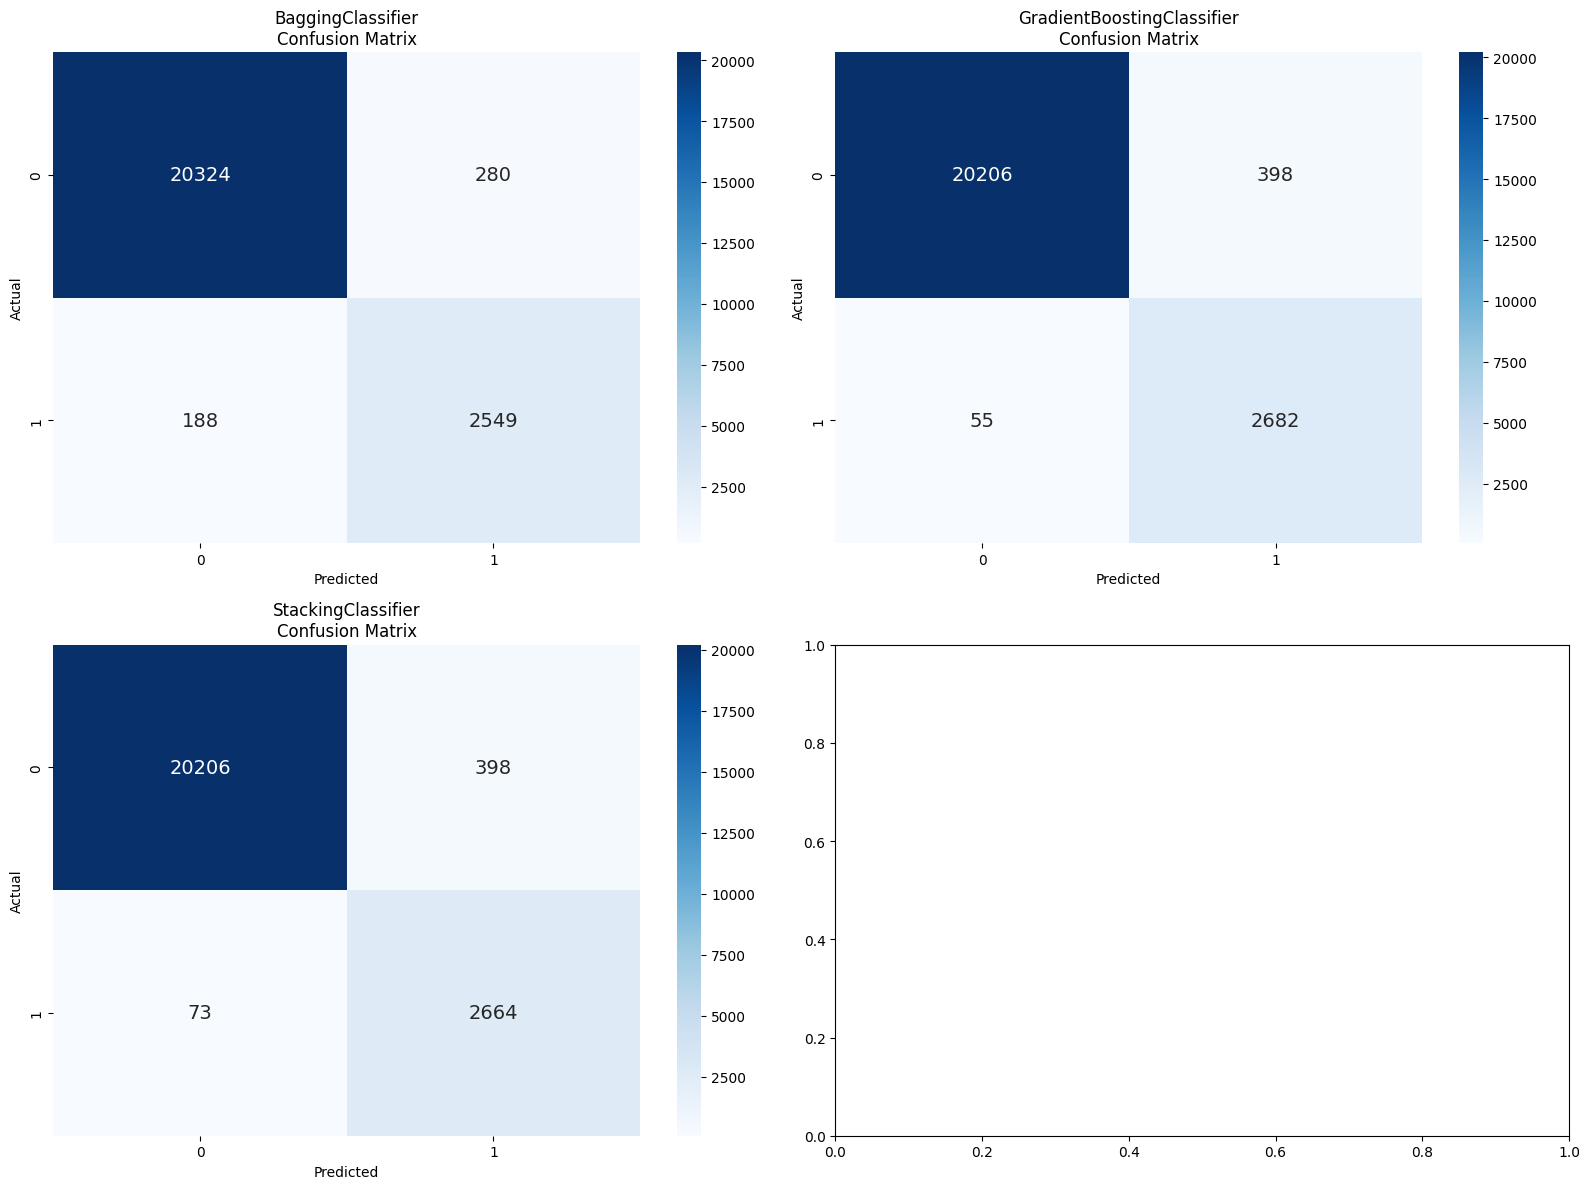

Сводная таблица результатов
                     Model  Accuracy  Precision  Recall  F1-score  FP (Error I)  FN (Error II)
         BaggingClassifier    0.9799     0.9010  0.9313    0.9159           280            188
GradientBoostingClassifier    0.9806     0.8708  0.9799    0.9221           398             55
        StackingClassifier    0.9798     0.8700  0.9733    0.9188           398             73


In [115]:
from sklearn.metrics import  precision_score, recall_score
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

results_summary = []

for idx, (name, y_pred) in enumerate(predictions2.items()):
    # Classification Report
    print(f"\n")
    print(f"{name}")
    print(classification_report(y_test_cls, y_pred, digits=4))
    
    # Матрица ошибок
    cm = confusion_matrix(y_test_cls, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                annot_kws={'size': 14})
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12)
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

    cm = confusion_matrix(y_test_cls, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_test_cls, y_pred)
    precision = precision_score(y_test_cls, y_pred)
    recall = recall_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)
    
    results_summary.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'FP (Error I)': fp,
        'FN (Error II)': fn
    })

plt.tight_layout()
plt.show()

print("Сводная таблица результатов")

import pandas as pd
results_df = pd.DataFrame(results_summary)
print(results_df.round(4).to_string(index=False))

### Регрессия
- **GradientBoostingRegressor** показал лучший результат: **R² = 0.344**, **MAPE = 17.74%**
- Оптимизация гиперпараметров улучшила R² на **79%** (с 0.19 до 0.34)

### Классификация
- **GradientBoostingClassifier** — лучшая модель: **Accuracy = 98.06%**, **Recall = 97.99%**, всего **55 пропусков**
- BaggingClassifier лучше по ложным срабатываниям (281), но хуже находит цели
- Все ансамбли показывают стабильно высокое качество (~98%)

**Gradient Boosting** — оптимальный выбор как для регрессии, так и для классификации. Для регрессии качество улучшилось, но остается средним (R²=0.34). Для классификации модели готовы к практическому использованию.

#  Модели градиентного бустинга

In [63]:
def optimize_xgb_classifier(X, y, n_trials=35):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
        model = xgb.XGBClassifier(**params, random_state=42, eval_metric='logloss')
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        return scores.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value

In [64]:
def optimize_xgb_regressor(X, y, n_trials=35):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        }
        model = xgb.XGBRegressor(**params, random_state=42, eval_metric='rmse')
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
        return -scores.mean()
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value

In [ ]:
print("XGBoost Classifier")
best_params, best_score = optimize_xgb_classifier(X_train_cls, y_train_cls, n_trials=30)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV accuracy: {best_score:.4f}")

# Рассчитываем scale_pos_weight для балансировки
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_cls)
weights = compute_class_weight('balanced', classes=classes, y=y_train_cls)
scale_pos_weight = weights[1] / weights[0]  # для бинарной классификации

xgb_cls = xgb.XGBClassifier(
    **best_params, 
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight  
)
xgb_cls.fit(X_train_cls, y_train_cls)

[I 2026-04-02 11:29:54,865] A new study created in memory with name: no-name-b496098a-92e2-45cf-b32b-8e227ccde017


XGBoost Classifier


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-02 11:29:56,950] Trial 0 finished with value: 0.9821342501847626 and parameters: {'n_estimators': 225, 'max_depth': 10, 'learning_rate': 0.019079244793710076, 'subsample': 0.7028512644028333, 'colsample_bytree': 0.6065568918955079, 'gamma': 4.949914019932439, 'reg_alpha': 1.943674933066609e-06, 'reg_lambda': 0.0006016270744277321}. Best is trial 0 with value: 0.9821342501847626.
[I 2026-04-02 11:29:58,139] Trial 1 finished with value: 0.9822306481154204 and parameters: {'n_estimators': 218, 'max_depth': 10, 'learning_rate': 0.17903099351926144, 'subsample': 0.9454782338704317, 'colsample_bytree': 0.540411838849749, 'gamma': 3.5400301157831477, 'reg_alpha': 1.9743521911597526, 'reg_lambda': 0.061885914154209395}. Best is trial 1 with value: 0.9822306481154204.
[I 2026-04-02 11:29:59,610] Trial 2 finished with value: 0.9819307434422629 and parameters: {'n_estimators': 265, 'max_depth': 6, 'learning_rate': 0.08727375664677059, 'subsample': 0.5916590030265565, 'colsample_bytree'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7852814829570616, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=0.42453320001953965, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.036492608521404256,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=11, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=265, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [66]:
print("XGBoost Regressor")
best_params, best_score = optimize_xgb_regressor(X_train_reg, y_train_reg, n_trials=30)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV MSE: {best_score:.4f}")
xgb_reg = xgb.XGBRegressor(**best_params, random_state=42, eval_metric='rmse')
xgb_reg.fit(X_train_reg, y_train_reg)

[I 2026-04-02 11:17:35,522] A new study created in memory with name: no-name-447ffeb5-4d64-41a9-a5c2-09aa9b7b2d4d


XGBoost Regressor


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-02 11:17:35,776] Trial 0 finished with value: 97.19595845540364 and parameters: {'n_estimators': 214, 'max_depth': 6, 'learning_rate': 0.1260079940629225, 'subsample': 0.7548469810762286, 'colsample_bytree': 0.9590895520288389, 'gamma': 4.437610977533144, 'reg_alpha': 0.000823648379114785, 'reg_lambda': 5.69750571340992}. Best is trial 0 with value: 97.19595845540364.
[I 2026-04-02 11:17:36,274] Trial 1 finished with value: 100.42908986409505 and parameters: {'n_estimators': 148, 'max_depth': 10, 'learning_rate': 0.11330340208360119, 'subsample': 0.8034558660640028, 'colsample_bytree': 0.871875113834631, 'gamma': 0.512963469384447, 'reg_alpha': 0.027074183265874147, 'reg_lambda': 0.9468727574705406}. Best is trial 0 with value: 97.19595845540364.
[I 2026-04-02 11:17:36,687] Trial 2 finished with value: 99.85099538167317 and parameters: {'n_estimators': 124, 'max_depth': 10, 'learning_rate': 0.14643090834715203, 'subsample': 0.5646887429734602, 'colsample_bytree': 0.997533110

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7130871806225918, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, gamma=4.996964471957739,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.010044003454385218,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=11, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=264, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [78]:
y_pred_xgb_cls = xgb_cls.predict(X_test_cls)
y_pred_xgb_reg = xgb_reg.predict(X_test_reg)

In [68]:
def optimize_lgb_classifier(X, y, n_trials=35):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 2, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        }
        model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1)
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        return scores.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value

In [69]:
def optimize_lgb_regressor(X, y, n_trials=35):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 2, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        }
        model = lgb.LGBMRegressor(**params, random_state=42, verbose=-1)
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
        return -scores.mean()
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value

In [79]:
print("LightGBM Classifier")
best_params, best_score = optimize_lgb_classifier(X_train_cls, y_train_cls, n_trials=30)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV accuracy: {best_score:.4f}")

lgb_cls = lgb.LGBMClassifier(
    **best_params, 
    random_state=42, 
    verbose=-1,
    class_weight='balanced'  # автоматическая балансировка
)
lgb_cls.fit(X_train_cls, y_train_cls)

[I 2026-04-02 11:31:03,426] A new study created in memory with name: no-name-ab281f37-7123-4bd1-94b4-f73f2b5373e2


LightGBM Classifier


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-02 11:31:03,857] Trial 0 finished with value: 0.9812988014523955 and parameters: {'n_estimators': 113, 'max_depth': 3, 'learning_rate': 0.2213978364725804, 'num_leaves': 218, 'subsample': 0.5912888197828575, 'colsample_bytree': 0.5418674640558622, 'reg_alpha': 0.6150368377575396, 'reg_lambda': 0.6331573275105914}. Best is trial 0 with value: 0.9812988014523955.
[I 2026-04-02 11:31:04,954] Trial 1 finished with value: 0.9827340595310776 and parameters: {'n_estimators': 118, 'max_depth': 12, 'learning_rate': 0.03307875037996851, 'num_leaves': 223, 'subsample': 0.505006757477892, 'colsample_bytree': 0.8749663128943936, 'reg_alpha': 0.952704656770853, 'reg_lambda': 0.7245178881743749}. Best is trial 1 with value: 0.9827340595310776.
[I 2026-04-02 11:31:08,326] Trial 2 finished with value: 0.9826269507192356 and parameters: {'n_estimators': 147, 'max_depth': 12, 'learning_rate': 0.022374383836483693, 'num_leaves': 141, 'subsample': 0.752650227397508, 'colsample_bytree': 0.7139067

LGBMClassifier(class_weight='balanced', colsample_bytree=0.5101901907864959,
               learning_rate=0.04418234704541104, max_depth=11,
               n_estimators=262, num_leaves=193, random_state=42,
               reg_alpha=0.020042187499270003, reg_lambda=0.16445456111085738,
               subsample=0.6626502107888956, verbose=-1)

In [71]:
print("LightGBM Regressor")
best_params, best_score = optimize_lgb_regressor(X_train_reg, y_train_reg, n_trials=30)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV MSE: {best_score:.4f}")
lgb_reg = lgb.LGBMRegressor(**best_params, random_state=42, verbose=-1)
lgb_reg.fit(X_train_reg, y_train_reg)

[I 2026-04-02 11:18:33,488] A new study created in memory with name: no-name-34252ba2-a0c2-4135-90ed-f9c7c34c2f1b


LightGBM Regressor


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-02 11:18:33,631] Trial 0 finished with value: 95.92357769866874 and parameters: {'n_estimators': 88, 'max_depth': 12, 'learning_rate': 0.07667023856662185, 'num_leaves': 24, 'subsample': 0.9878665162647107, 'colsample_bytree': 0.7739413220265982, 'reg_alpha': 0.6594817271402915, 'reg_lambda': 0.09883186306060054}. Best is trial 0 with value: 95.92357769866874.
[I 2026-04-02 11:18:33,774] Trial 1 finished with value: 98.76277274776119 and parameters: {'n_estimators': 93, 'max_depth': 5, 'learning_rate': 0.04551718021331471, 'num_leaves': 150, 'subsample': 0.8697289377132038, 'colsample_bytree': 0.9112990974252864, 'reg_alpha': 0.8197422145933992, 'reg_lambda': 0.056177940103982915}. Best is trial 0 with value: 95.92357769866874.
[I 2026-04-02 11:18:33,983] Trial 2 finished with value: 105.268820551477 and parameters: {'n_estimators': 65, 'max_depth': 7, 'learning_rate': 0.013558380139521856, 'num_leaves': 139, 'subsample': 0.78124936385829, 'colsample_bytree': 0.6870553568194

LGBMRegressor(colsample_bytree=0.5823227981230787,
              learning_rate=0.016671834928546066, max_depth=8, n_estimators=282,
              num_leaves=220, random_state=42, reg_alpha=0.7786851788414082,
              reg_lambda=0.6774561904123773, subsample=0.951540656269918,
              verbose=-1)

In [80]:
y_pred_lgb_cls = lgb_cls.predict(X_test_cls)
y_pred_lgb_reg = lgb_reg.predict(X_test_reg)

In [73]:
def optimize_catboost_classifier(X, y, n_trials=35):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 500),
            'depth': trial.suggest_int('depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'border_count': trial.suggest_int('border_count', 32, 255),
        }
        model = cb.CatBoostClassifier(**params, random_seed=42, verbose=False)
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        return scores.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value

In [74]:
def optimize_catboost_regressor(X, y, n_trials=35):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 500),
            'depth': trial.suggest_int('depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'border_count': trial.suggest_int('border_count', 32, 255),
        }
        model = cb.CatBoostRegressor(**params, random_seed=42, verbose=False)
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
        return -scores.mean()
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value

In [76]:
print("CatBoost Classifier")
best_params, best_score = optimize_catboost_classifier(X_train_cls, y_train_cls, n_trials=30)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV accuracy: {best_score:.4f}")

cat_cls = cb.CatBoostClassifier(
    **best_params, 
    random_seed=42, 
    verbose=False,
    auto_class_weights='Balanced',  # автоматическая балансировка
    thread_count=-1
)
cat_cls.fit(X_train_cls, y_train_cls)  # оригинальные НЕсбалансированные данные

[I 2026-04-02 11:22:48,025] A new study created in memory with name: no-name-7d7fdad9-e6c9-4f63-898a-48372cebf1bf


CatBoost Classifier


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-02 11:22:53,659] Trial 0 finished with value: 0.9827233486498934 and parameters: {'iterations': 441, 'depth': 4, 'learning_rate': 0.24216410832002339, 'l2_leaf_reg': 6.285995963002319, 'border_count': 108}. Best is trial 0 with value: 0.9827233486498934.
[I 2026-04-02 11:22:59,835] Trial 1 finished with value: 0.9804205091952914 and parameters: {'iterations': 421, 'depth': 6, 'learning_rate': 0.010022220635146703, 'l2_leaf_reg': 9.763517021971087, 'border_count': 157}. Best is trial 0 with value: 0.9827233486498934.
[I 2026-04-02 11:23:10,913] Trial 2 finished with value: 0.9821342501847626 and parameters: {'iterations': 379, 'depth': 9, 'learning_rate': 0.1929167920871817, 'l2_leaf_reg': 3.2800566138174827, 'border_count': 143}. Best is trial 0 with value: 0.9827233486498934.
[I 2026-04-02 11:23:12,051] Trial 3 finished with value: 0.9797885672054241 and parameters: {'iterations': 108, 'depth': 7, 'learning_rate': 0.05827165991966706, 'l2_leaf_reg': 1.8158753107677916, 'bor

CatBoostClassifier(auto_class_weights='Balanced', border_count=159, depth=5, iterations=381, l2_leaf_reg=6.840248293699637, learning_rate=0.14768305939455362, random_seed=42, verbose=False)

In [81]:
print("CatBoost Regressor")
best_params, best_score = optimize_catboost_regressor(X_train_reg, y_train_reg, n_trials=30)
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая CV MSE: {best_score:.4f}")
cat_reg = cb.CatBoostRegressor(**best_params, random_seed=42, verbose=False)
cat_reg.fit(X_train_reg, y_train_reg)

[I 2026-04-02 11:37:28,007] A new study created in memory with name: no-name-583251fb-9c6d-4855-a88b-ba387fa96342


CatBoost Regressor


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-02 11:37:29,884] Trial 0 finished with value: 99.54926207135685 and parameters: {'iterations': 107, 'depth': 3, 'learning_rate': 0.2730545777575415, 'l2_leaf_reg': 8.633720020416447, 'border_count': 129}. Best is trial 0 with value: 99.54926207135685.
[I 2026-04-02 11:37:31,599] Trial 1 finished with value: 99.95827857520779 and parameters: {'iterations': 137, 'depth': 7, 'learning_rate': 0.03786892842614346, 'l2_leaf_reg': 6.4203627415858415, 'border_count': 62}. Best is trial 0 with value: 99.54926207135685.
[I 2026-04-02 11:37:33,514] Trial 2 finished with value: 97.61571334415362 and parameters: {'iterations': 357, 'depth': 4, 'learning_rate': 0.051168955176656185, 'l2_leaf_reg': 1.8484326778734848, 'border_count': 146}. Best is trial 2 with value: 97.61571334415362.
[I 2026-04-02 11:37:35,336] Trial 3 finished with value: 105.1800731158615 and parameters: {'iterations': 370, 'depth': 4, 'learning_rate': 0.011717081769950918, 'l2_leaf_reg': 2.793657694405161, 'border_cou

CatBoostRegressor(border_count=224, depth=9, iterations=296, l2_leaf_reg=5.4213376931031165, learning_rate=0.06775772459347705, loss_function='RMSE', random_seed=42, verbose=False)

In [82]:
y_pred_cat_cls = cat_cls.predict(X_test_cls)
y_pred_cat_reg = cat_reg.predict(X_test_reg)

In [83]:
predictions3 = {
    'XGBoost Regressor': y_pred_xgb_reg,
    'LightGBM Regressor': y_pred_lgb_reg,
    'CatBoost Regressor': y_pred_cat_reg
}
predictions4 = {
    'XGBoost Classifier': y_pred_xgb_cls,
    'LightGBM Classifier': y_pred_lgb_cls,
    'CatBoost Classifier': y_pred_cat_cls
}

In [116]:
results = []
for name, y_pred in predictions3.items():
    metrics = calculate_metrics(y_test_reg, y_pred, name)
    results.append({'Модель': name, **metrics})

# Выводим в виде таблицы
print(f"\n{'Модель':<15} {'R²':<10} {'MAE':<10} {'MSE':<12} {'RMSE':<10} {'MAPE':<10}")
print("-" * 70)

for item in results:
    print(f"{item['Модель']:<15} {item['R2']:<10.4f} {item['MAE']:<10.2f} {item['MSE']:<12.2f} {item['RMSE']:<10.2f} {item['MAPE']:<10.2f}%")


Модель          R²         MAE        MSE          RMSE       MAPE      
----------------------------------------------------------------------
XGBoost Regressor 0.3771     7.27       86.32        9.29       17.32     %
LightGBM Regressor 0.3124     7.61       95.29        9.76       18.36     %
CatBoost Regressor 0.3117     7.63       95.39        9.77       18.32     %




XGBoost Classifier
              precision    recall  f1-score   support

           0     0.9963    0.9829    0.9895     20604
           1     0.8832    0.9722    0.9256      2737

    accuracy                         0.9817     23341
   macro avg     0.9397    0.9776    0.9576     23341
weighted avg     0.9830    0.9817    0.9820     23341



LightGBM Classifier
              precision    recall  f1-score   support

           0     0.9968    0.9828    0.9898     20604
           1     0.8831    0.9766    0.9275      2737

    accuracy                         0.9821     23341
   macro avg     0.9400    0.9797    0.9586     23341
weighted avg     0.9835    0.9821    0.9825     23341



CatBoost Classifier
              precision    recall  f1-score   support

           0     0.9988    0.9780    0.9883     20604
           1     0.8569    0.9912    0.9192      2737

    accuracy                         0.9796     23341
   macro avg     0.9279    0.9846    0.9537     23341
weighted 

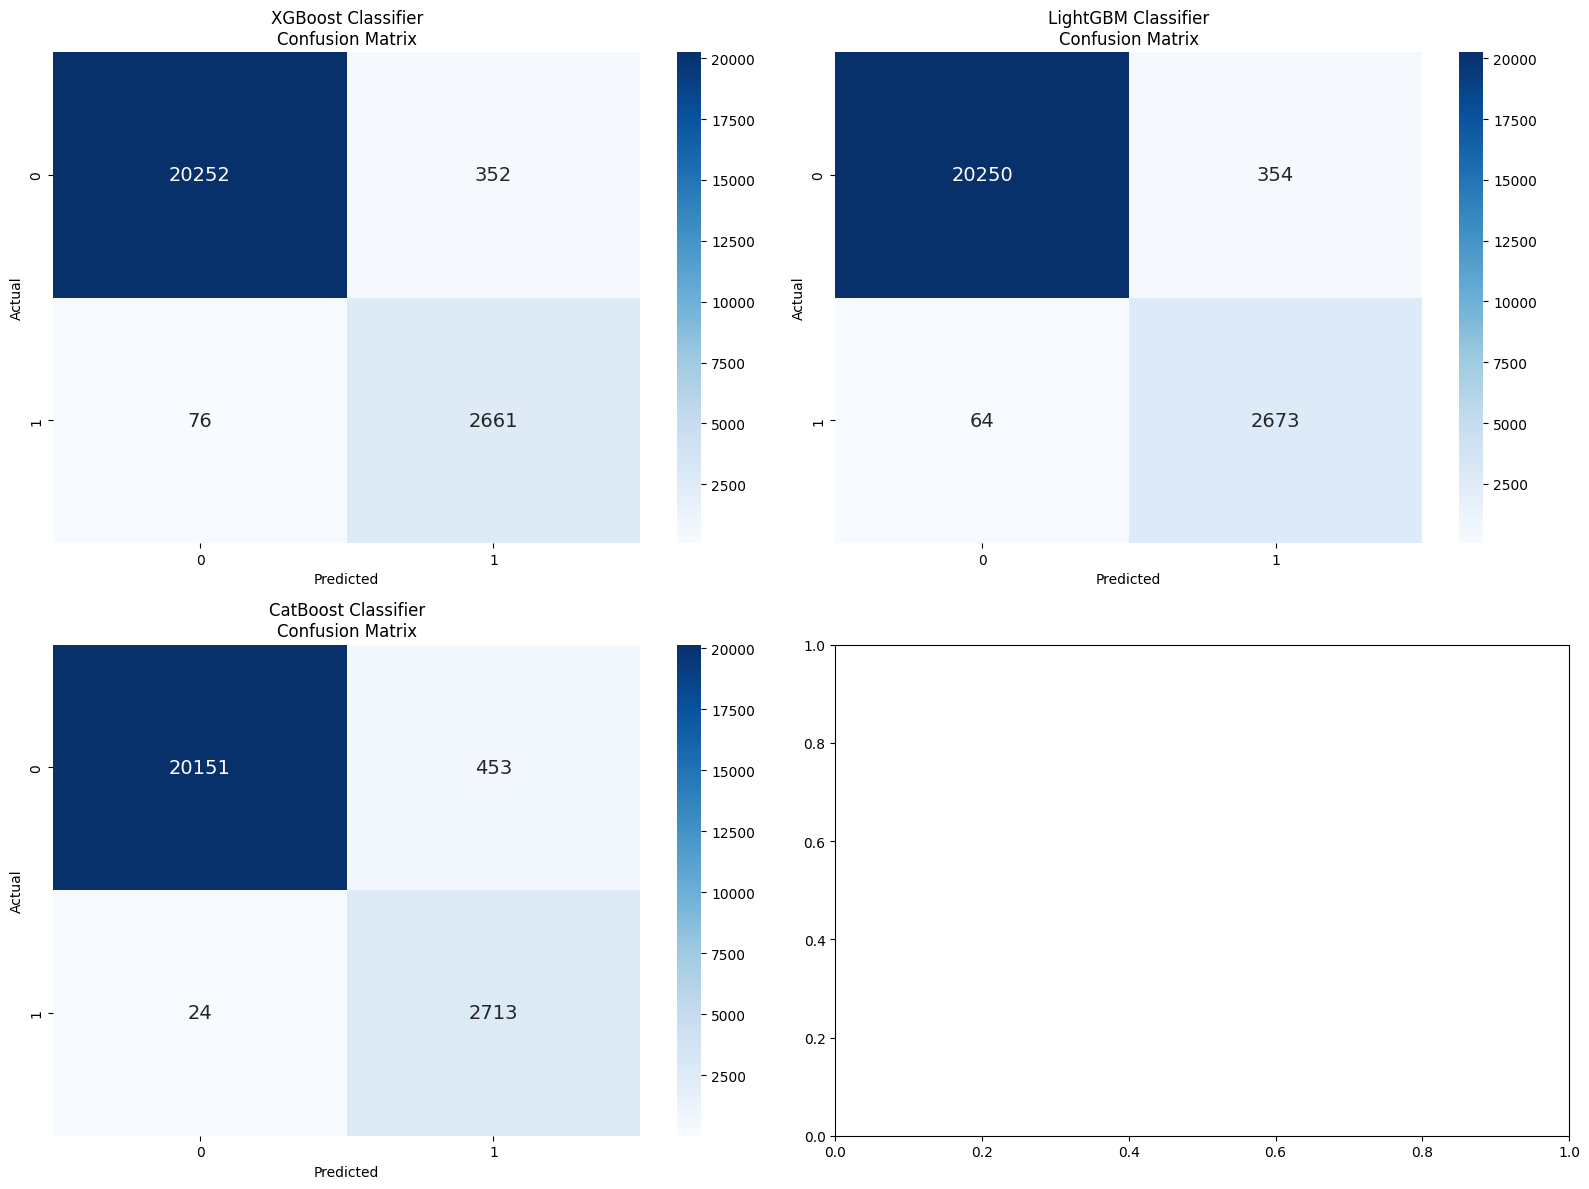

Сводная таблица результатов
              Model  Accuracy  Precision  Recall  F1-score  FP (Error I)  FN (Error II)
 XGBoost Classifier    0.9817     0.8832  0.9722    0.9256           352             76
LightGBM Classifier    0.9821     0.8831  0.9766    0.9275           354             64
CatBoost Classifier    0.9796     0.8569  0.9912    0.9192           453             24


In [117]:
from sklearn.metrics import  precision_score, recall_score
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

results_summary = []

for idx, (name, y_pred) in enumerate(predictions4.items()):
    # Classification Report
    print(f"\n")
    print(f"{name}")
    print(classification_report(y_test_cls, y_pred, digits=4))
    
    # Матрица ошибок
    cm = confusion_matrix(y_test_cls, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                annot_kws={'size': 14})
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12)
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

    cm = confusion_matrix(y_test_cls, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_test_cls, y_pred)
    precision = precision_score(y_test_cls, y_pred)
    recall = recall_score(y_test_cls, y_pred)
    f1 = f1_score(y_test_cls, y_pred)
    
    results_summary.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'FP (Error I)': fp,
        'FN (Error II)': fn
    })

plt.tight_layout()
plt.show()

print("Сводная таблица результатов")

import pandas as pd
results_df = pd.DataFrame(results_summary)
print(results_df.round(4).to_string(index=False))

### Регрессия
- **XGBoost Regressor** показал лучший результат: **R² = 0.377**, **MAPE = 17.32%**, **RMSE = 9.29**
- GradientBoostingRegressor на втором месте (R² = 0.344)
- Все модели регрессии показывают **низкое качество** (R² < 0.4) — данные плохо предсказуемы

### Классификация

- **LightGBM** — лучший по общей точности (98.21%) и F1-score
- **CatBoost** — лучший по полноте (99.12%), почти не пропускает цели
- **Bagging** — лучший по точности, меньше всего ложных срабатываний
- **GradientBoosting** — хороший баланс между всеми метриками

### Итог

- **Для регрессии:** XGBoost — лучший, но качество низкое (R²=0.38)
- **Для классификации:** LightGBM / CatBoost / GradientBoosting — все показывают отличные результаты (≈98% accuracy)
- **Для минимизации пропусков:** CatBoost (всего 24 пропуска из 2737)

# Собственная реализация дерева CART

### Критерии качества разбиения в дереве CART

#### 1. Индекс Джини (Gini) — для задачи классификации

Мера неопределенности (примеси) набора данных:

$$Gini = 1 - \sum_{i=1}^{C} p_i^2$$

где:
- $C$ — количество классов
- $p_i$ — доля объектов $i$-го класса в узле

**Свойства:** $Gini \in [0, 1]$, где $0$ — узел полностью чист (все объекты одного класса), $1$ — максимальная неопределенность.


#### 2. Среднеквадратичная ошибка (MSE) — для задачи регрессии

Мера разброса значений целевой переменной в узле:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2$$

где:
- $n$ — количество объектов в узле
- $y_i$ — значение целевой переменной $i$-го объекта
- $\bar{y}$ — среднее значение целевой переменной в узле

#### 3. Взвешенная примесь (Weighted Impurity) — для оценки качества разбиения

При разбиении узла на левый и правый дочерние узлы качество разбиения оценивается как взвешенная сумма примесей дочерних узлов:

$$I_{\text{weighted}} = \frac{n_{\text{left}}}{n} \cdot I_{\text{left}} + \frac{n_{\text{right}}}{n} \cdot I_{\text{right}}$$

где:
- $n$ — общее количество объектов в родительском узле
- $n_{\text{left}}$, $n_{\text{right}}$ — количество объектов в левом и правом дочерних узлах
- $I_{\text{left}}$, $I_{\text{right}}$ — значение примеси (Gini или MSE) для дочерних узлов

**Лучшее разбиение** минимизирует взвешенную примесь:

$$\text{best\_split} = \arg \min I_{\text{weighted}}$$

In [118]:
import numpy as np
from collections import Counter

class CARTTree:
    def __init__(self, max_depth=5, min_samples_split=2, min_samples_leaf=1, task='classification'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.task = task
        self.tree = None
        self.n_features = None
    
    def _gini(self, y):
        if len(y) == 0:
            return 0
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)
    
    def _mse(self, y):
        if len(y) == 0:
            return 0
        return np.var(y)
    
    def _weighted_impurity(self, y_left, y_right, impurity_func):
        n = len(y_left) + len(y_right)
        if n == 0:
            return float('inf')
        return (len(y_left) / n) * impurity_func(y_left) + (len(y_right) / n) * impurity_func(y_right)
    
    
    def _find_best_split(self, X, y):
        n_samples, n_features = X.shape
        best_feature = None
        best_threshold = None
        best_impurity = float('inf')
        
        # Выбираем функцию примеси в зависимости от задачи
        impurity_func = self._gini if self.task == 'classification' else self._mse
        
        # Текущая примесь до разбиения
        current_impurity = impurity_func(y)
        
        # Перебираем все признаки
        for feature in range(n_features):
            # Получаем уникальные значения признака
            values = np.unique(X[:, feature])
            
            # Если значений мало, пропускаем
            if len(values) <= 1:
                continue
            
            # Перебираем возможные пороги (середины между значениями)
            for i in range(len(values) - 1):
                threshold = (values[i] + values[i + 1]) / 2
                
                # Разбиваем выборку
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                
                # Проверяем минимальное количество образцов
                if np.sum(left_mask) < self.min_samples_leaf or np.sum(right_mask) < self.min_samples_leaf:
                    continue
                
                # Вычисляем взвешенную примесь
                y_left = y[left_mask]
                y_right = y[right_mask]
                impurity = self._weighted_impurity(y_left, y_right, impurity_func)
                
                # Обновляем лучшее разбиение
                if impurity < best_impurity:
                    best_impurity = impurity
                    best_feature = feature
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_impurity
    
    
    def _build_tree(self, X, y, depth=0):
        n_samples = len(y)
        n_classes = len(np.unique(y))
        
        # Условия остановки
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            n_classes == 1):
            return self._create_leaf_node(y)
        
        # Поиск лучшего разбиения
        feature, threshold, impurity = self._find_best_split(X, y)
        
        # Если не нашли подходящего разбиения, создаем лист
        if feature is None:
            return self._create_leaf_node(y)
        
        # Разбиваем выборку
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        # Проверяем, что оба подмножества не пусты
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return self._create_leaf_node(y)
        
        # Рекурсивно строим поддеревья
        left_tree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_tree = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        # Возвращаем узел
        return {
            'feature': feature,
            'threshold': threshold,
            'left': left_tree,
            'right': right_tree,
            'is_leaf': False,
            'n_samples': n_samples,
            'impurity': impurity
        }
    
    def _create_leaf_node(self, y):
        if self.task == 'classification':
            # Для классификации: наиболее частый класс
            classes, counts = np.unique(y, return_counts=True)
            prediction = classes[np.argmax(counts)]
            probabilities = counts / len(y)
        else:
            # Для регрессии: среднее значение
            prediction = np.mean(y)
            probabilities = None
        
        return {
            'prediction': prediction,
            'is_leaf': True,
            'n_samples': len(y),
            'probabilities': probabilities
        }
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.n_features = X.shape[1]
        self.tree = self._build_tree(X, y)
        return self
    
    
    def _predict_single(self, x, node):
        if node['is_leaf']:
            return node['prediction']
        
        if x[node['feature']] <= node['threshold']:
            return self._predict_single(x, node['left'])
        else:
            return self._predict_single(x, node['right'])
    
    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_single(x, self.tree) for x in X])
    
    
    def print_tree(self, node=None, depth=0, feature_names=None, depth_limit=None):
        if node is None:
            node = self.tree
        
        # Проверяем, нужно ли останавливаться
        if depth_limit is not None and depth >= depth_limit:
            if node['is_leaf']:
                if self.task == 'classification':
                    print(f"{'  ' * depth}Leaf: class = {node['prediction']}, samples = {node['n_samples']}")
                else:
                    print(f"{'  ' * depth}Leaf: value = {node['prediction']:.4f}, samples = {node['n_samples']}")
            else:
                print(f"{'  ' * depth}[... truncated at depth {depth_limit} ...]")
            return
        
        indent = "  " * depth
        
        if node['is_leaf']:
            if self.task == 'classification':
                print(f"{indent}Leaf: class = {node['prediction']}, samples = {node['n_samples']}")
            else:
                print(f"{indent}Leaf: value = {node['prediction']:.4f}, samples = {node['n_samples']}")
        else:
            feature = f"feature_{node['feature']}" if feature_names is None else feature_names[node['feature']]
            print(f"{indent}Node: {feature} <= {node['threshold']:.4f}, samples = {node['n_samples']}")
            print(f"{indent}  Left:")
            self.print_tree(node['left'], depth + 1, feature_names, depth_limit)
            print(f"{indent}  Right:")
            self.print_tree(node['right'], depth + 1, feature_names, depth_limit)
    
    def get_depth(self, node=None):
        if node is None:
            node = self.tree
        
        if node['is_leaf']:
            return 0
        
        return 1 + max(self.get_depth(node['left']), self.get_depth(node['right']))
    
    def get_n_nodes(self, node=None):
        if node is None:
            node = self.tree
        
        if node['is_leaf']:
            return 1
        
        return 1 + self.get_n_nodes(node['left']) + self.get_n_nodes(node['right'])


## Обучение собственного дерева CART (Классификация)

In [119]:
# Создаем и обучаем дерево
cart_cls = CARTTree(max_depth=5, min_samples_split=2, min_samples_leaf=1, task='classification')
cart_cls.fit(X_train_cls, y_train_cls)

# Предсказания
y_pred_cart_cls = cart_cls.predict(X_test_cls)
y_pred_train_cart_cls = cart_cls.predict(X_train_cls)

# Вычисляем метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy_cls = accuracy_score(y_test_cls, y_pred_cart_cls)
precision_cls = precision_score(y_test_cls, y_pred_cart_cls, average='weighted')
recall_cls = recall_score(y_test_cls, y_pred_cart_cls, average='weighted')
f1_cls = f1_score(y_test_cls, y_pred_cart_cls, average='weighted')

print(f"\nМетрики собственного дерева CART (классификация):")
print(f"  Accuracy:  {accuracy_cls:.4f}")
print(f"  Precision: {precision_cls:.4f}")
print(f"  Recall:    {recall_cls:.4f}")
print(f"  F1-score:  {f1_cls:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test_cls, y_pred_cart_cls, digits=4))

print(f"\nСтруктура дерева (первые 3 уровня):")
cart_cls.print_tree(depth_limit=3)

print(f"\nГлубина дерева: {cart_cls.get_depth()}")
print(f"Количество узлов: {cart_cls.get_n_nodes()}")



Метрики собственного дерева CART (классификация):
  Accuracy:  0.9707
  Precision: 0.9719
  Recall:    0.9707
  F1-score:  0.9711

Classification Report:
              precision    recall  f1-score   support

           0     0.9883    0.9784    0.9833     20604
           1     0.8485    0.9127    0.8794      2737

    accuracy                         0.9707     23341
   macro avg     0.9184    0.9455    0.9314     23341
weighted avg     0.9719    0.9707    0.9711     23341


Структура дерева (первые 3 уровня):
Node: feature_14 <= 39.5000, samples = 93363
  Left:
  Node: feature_15 <= 885.0000, samples = 19822
    Left:
    Node: feature_4 <= 352.5000, samples = 12144
      Left:
      [... truncated at depth 3 ...]
      Right:
      [... truncated at depth 3 ...]
    Right:
    Node: feature_15 <= 975.0000, samples = 7678
      Left:
      [... truncated at depth 3 ...]
      Right:
      [... truncated at depth 3 ...]
  Right:
  Node: feature_14 <= 40.5000, samples = 73541
    Lef

## Обучение собственного дерева CART (Регрессия)

In [92]:
# Создаем и обучаем дерево
cart_reg = CARTTree(max_depth=5, min_samples_split=2, min_samples_leaf=1, task='regression')
cart_reg.fit(X_train_reg, y_train_reg)

# Предсказания
y_pred_cart_reg = cart_reg.predict(X_test_reg)
y_pred_train_cart_reg = cart_reg.predict(X_train_reg)

# Вычисляем метрики
mse_cart = mean_squared_error(y_test_reg, y_pred_cart_reg)
rmse_cart = np.sqrt(mse_cart)
mae_cart = mean_absolute_error(y_test_reg, y_pred_cart_reg)
r2_cart = r2_score(y_test_reg, y_pred_cart_reg)

print(f"\nМетрики собственного дерева CART (регрессия):")
print(f"  MSE:  {mse_cart:.4f}")
print(f"  RMSE: {rmse_cart:.4f}")
print(f"  MAE:  {mae_cart:.4f}")
print(f"  R²:   {r2_cart:.4f}")

print(f"\nСтруктура дерева (первые 3 уровня):")
cart_reg.print_tree(depth_limit=3)

print(f"\nГлубина дерева: {cart_reg.get_depth()}")
print(f"Количество узлов: {cart_reg.get_n_nodes()}")


Метрики собственного дерева CART (регрессия):
  MSE:  111.2323
  RMSE: 10.5467
  MAE:  8.2210
  R²:   0.1973

Структура дерева (первые 3 уровня):
Node: feature_15 <= 21.5000, samples = 4548
  Left:
  Node: feature_7 <= 20.5000, samples = 1446
    Left:
    Node: feature_15 <= 19.5000, samples = 1219
      Left:
      [... truncated at depth 3 ...]
      Right:
      [... truncated at depth 3 ...]
    Right:
    Node: feature_27 <= 3.5000, samples = 227
      Left:
      [... truncated at depth 3 ...]
      Right:
      [... truncated at depth 3 ...]
  Right:
  Node: feature_20 <= 762.5000, samples = 3102
    Left:
    Node: feature_13 <= 20.5000, samples = 2509
      Left:
      [... truncated at depth 3 ...]
      Right:
      [... truncated at depth 3 ...]
    Right:
    Node: feature_3 <= 21.5000, samples = 593
      Left:
      [... truncated at depth 3 ...]
      Right:
      [... truncated at depth 3 ...]

Глубина дерева: 5
Количество узлов: 61


## Сравнение с sklearn DecisionTree

In [89]:
# Сравнение классификации
print(f"\nСравнение классификации:")
print(f"  Собственная реализация CART:")
print(f"    Accuracy: {accuracy_cls:.4f}, F1-score: {f1_cls:.4f}")
print(f"  sklearn DecisionTreeClassifier:")
print(f"    Accuracy: {accuracy_score(y_test_cls, dt_cls.predict(X_test_cls)):.4f}, "
      f"F1-score: {f1_score(y_test_cls, dt_cls.predict(X_test_cls), average='weighted'):.4f}")

# Сравнение регрессии
print(f"\nСравнение регрессии:")
print(f"  Собственная реализация CART:")
print(f"    R²: {r2_cart:.4f}, RMSE: {rmse_cart:.4f}")
print(f"  sklearn DecisionTreeRegressor:")
print(f"    R²: {r2_score(y_test_reg, dt_reg.predict(X_test_reg)):.4f}, "
      f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, dt_reg.predict(X_test_reg))):.4f}")


Сравнение классификации:
  Собственная реализация CART:
    Accuracy: 0.9707, F1-score: 0.9711
  sklearn DecisionTreeClassifier:
    Accuracy: 0.8827, F1-score: 0.8278

Сравнение регрессии:
  Собственная реализация CART:
    R²: 0.1973, RMSE: 10.5467
  sklearn DecisionTreeRegressor:
    R²: -0.4739, RMSE: 14.2916


# Собственная реализация Bagging

In [ ]:
class MyBaggingClassifier:
    
    def __init__(self, base_estimator=None, n_estimators=10, max_samples=0.8, 
                 max_features=0.8, bootstrap=True, bootstrap_features=False, random_state=None):
        self.base_estimator = base_estimator or DecisionTreeClassifier(max_depth=5, random_state=random_state)
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.bootstrap_features = bootstrap_features
        self.random_state = random_state
        self.estimators_ = []
        self.feature_indices_ = []
    
    def get_params(self, deep=True):
        return {
            'base_estimator': self.base_estimator,
            'n_estimators': self.n_estimators,
            'max_samples': self.max_samples,
            'max_features': self.max_features,
            'bootstrap': self.bootstrap,
            'bootstrap_features': self.bootstrap_features,
            'random_state': self.random_state
        }
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self
    
    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        n_features = X.shape[1]
        
        if self.bootstrap:
            sample_indices = np.random.choice(n_samples, int(self.max_samples * n_samples), replace=True)
        else:
            sample_indices = np.random.choice(n_samples, int(self.max_samples * n_samples), replace=False)
        
        if self.bootstrap_features:
            n_selected_features = int(self.max_features * n_features)
            feature_indices = np.random.choice(n_features, n_selected_features, replace=False)
        else:
            feature_indices = np.arange(n_features)
        
        X_sample = X[sample_indices][:, feature_indices]
        y_sample = y[sample_indices]
        
        return X_sample, y_sample, feature_indices
    
    def fit(self, X, y):
        np.random.seed(self.random_state)
        X = np.array(X)
        y = np.array(y)
        
        self.estimators_ = []
        self.feature_indices_ = []
        
        for i in range(self.n_estimators):
            X_sample, y_sample, feature_indices = self._bootstrap_sample(X, y)
            self.feature_indices_.append(feature_indices)
            
            # Клонируем базовый классификатор
            if hasattr(self.base_estimator, 'get_params'):
                estimator = self.base_estimator.__class__(**self.base_estimator.get_params())
            else:
                # Если нет get_params, создаем новый экземпляр с теми же параметрами
                estimator = self.base_estimator.__class__()
            
            estimator.fit(X_sample, y_sample)
            self.estimators_.append(estimator)
            
        return self
    
    def predict(self, X):
        X = np.array(X)
        predictions = []
        
        for estimator, feature_indices in zip(self.estimators_, self.feature_indices_):
            X_subset = X[:, feature_indices]
            pred = estimator.predict(X_subset)
            predictions.append(pred)
        
        predictions = np.array(predictions)
        from scipy.stats import mode
        return mode(predictions, axis=0)[0].ravel()


class MyBaggingRegressor:
    
    def __init__(self, base_estimator=None, n_estimators=10, max_samples=0.8,
                 max_features=0.8, bootstrap=True, bootstrap_features=False, random_state=None):
        self.base_estimator = base_estimator or DecisionTreeRegressor(max_depth=5, random_state=random_state)
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.bootstrap_features = bootstrap_features
        self.random_state = random_state
        self.estimators_ = []
        self.feature_indices_ = []
    
    def get_params(self, deep=True):
        return {
            'base_estimator': self.base_estimator,
            'n_estimators': self.n_estimators,
            'max_samples': self.max_samples,
            'max_features': self.max_features,
            'bootstrap': self.bootstrap,
            'bootstrap_features': self.bootstrap_features,
            'random_state': self.random_state
        }
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self
    
    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        n_features = X.shape[1]
        
        if self.bootstrap:
            sample_indices = np.random.choice(n_samples, int(self.max_samples * n_samples), replace=True)
        else:
            sample_indices = np.random.choice(n_samples, int(self.max_samples * n_samples), replace=False)
        
        if self.bootstrap_features:
            n_selected_features = int(self.max_features * n_features)
            feature_indices = np.random.choice(n_features, n_selected_features, replace=False)
        else:
            feature_indices = np.arange(n_features)
        
        X_sample = X[sample_indices][:, feature_indices]
        y_sample = y[sample_indices]
        
        return X_sample, y_sample, feature_indices
    
    def fit(self, X, y):
        np.random.seed(self.random_state)
        X = np.array(X)
        y = np.array(y)
        
        self.estimators_ = []
        self.feature_indices_ = []
        
        for i in range(self.n_estimators):
            X_sample, y_sample, feature_indices = self._bootstrap_sample(X, y)
            self.feature_indices_.append(feature_indices)
            
            if hasattr(self.base_estimator, 'get_params'):
                estimator = self.base_estimator.__class__(**self.base_estimator.get_params())
            else:
                estimator = self.base_estimator.__class__()
            
            estimator.fit(X_sample, y_sample)
            self.estimators_.append(estimator)
            
        return self
    
    def predict(self, X):
        X = np.array(X)
        predictions = []
        
        for estimator, feature_indices in zip(self.estimators_, self.feature_indices_):
            X_subset = X[:, feature_indices]
            pred = estimator.predict(X_subset)
            predictions.append(pred)
        
        return np.mean(predictions, axis=0)


## Обучение собственной реализации Bagging (Классификация)

In [ ]:
my_bagging_cls = MyBaggingClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=False,
    random_state=42
)
my_bagging_cls.fit(X_train_cls, y_train_cls)

y_pred_my_bagging_cls = my_bagging_cls.predict(X_test_cls)

# Метрики
acc_my_bagging = accuracy_score(y_test_cls, y_pred_my_bagging_cls)
f1_my_bagging = f1_score(y_test_cls, y_pred_my_bagging_cls, average='weighted')

print(f"\nМетрики MyBaggingClassifier:")
print(f"  Accuracy: {acc_my_bagging:.4f}")
print(f"  F1-score: {f1_my_bagging:.4f}")


Метрики MyBaggingClassifier:
  Accuracy: 0.9733
  F1-score: 0.9738


## Обучение собственной реализации Bagging (Регрессия)

In [65]:
my_bagging_reg = MyBaggingRegressor(
    base_estimator=DecisionTreeRegressor(max_depth=5, random_state=42),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=False,
    random_state=42
)
my_bagging_reg.fit(X_train_reg, y_train_reg)

y_pred_my_bagging_reg = my_bagging_reg.predict(X_test_reg)

r2_my_bagging = r2_score(y_test_reg, y_pred_my_bagging_reg)
rmse_my_bagging = np.sqrt(mean_squared_error(y_test_reg, y_pred_my_bagging_reg))

print(f"\nМетрики MyBaggingRegressor:")
print(f"  R²: {r2_my_bagging:.4f}")
print(f"  RMSE: {rmse_my_bagging:.4f}")


Метрики MyBaggingRegressor:
  R²: 0.2231
  RMSE: 10.3760


## Сравнение с sklearn ансамблями

In [ ]:
print(f"\nСравнение Bagging (Классификация):")
print(f"  MyBaggingClassifier:  Accuracy = {acc_my_bagging:.4f}, F1 = {f1_my_bagging:.4f}")
print(f"  sklearn Bagging:      Accuracy = {accuracy_score(y_test_cls, y_pred_bagging_cls):.4f}, "
      f"F1 = {f1_score(y_test_cls, y_pred_bagging_cls, average='weighted'):.4f}")

print(f"\nСравнение Bagging (Регрессия):")
print(f"  MyBaggingRegressor:   R² = {r2_my_bagging:.4f}, RMSE = {rmse_my_bagging:.4f}")
print(f"  sklearn Bagging:       R² = {r2_score(y_test_reg, y_pred_bagging_reg):.4f}, "
      f"RMSE = {np.sqrt(mean_squared_error(y_test_reg, y_pred_bagging_reg)):.4f}")



Сравнение Bagging (Классификация):
  MyBaggingClassifier:  Accuracy = 0.9733, F1 = 0.9738
  sklearn Bagging:      Accuracy = 0.9738, F1 = 0.9742

Сравнение Bagging (Регрессия):
  MyBaggingRegressor:   R² = 0.2231, RMSE = 10.3760
  sklearn Bagging:       R² = 0.2300, RMSE = 10.3295


# Собственная реализация Stacking

In [ ]:
class MyStackingClassifier:
    def __init__(self, estimators, final_estimator=None, cv=5):
        self.estimators = estimators
        self.final_estimator = final_estimator or LogisticRegression()
        self.cv = cv
        self.base_estimators_ = []
        self.meta_features_train_ = None
    
    def _clone_estimator(self, estimator):
        if hasattr(estimator, 'get_params'):
            return estimator.__class__(**estimator.get_params())
        else:
            return estimator.__class__()
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples = X.shape[0]
        
        # Обучаем базовые модели на всей выборке
        self.base_estimators_ = []
        for name, estimator in self.estimators:
            estimator_clone = self._clone_estimator(estimator)
            estimator_clone.fit(X, y)
            self.base_estimators_.append((name, estimator_clone))
        
        # Формируем мета-признаки с помощью кросс-валидации
        from sklearn.model_selection import KFold
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)
        meta_features = np.zeros((n_samples, len(self.estimators)))
        
        for i, (name, estimator) in enumerate(self.estimators):
            for train_idx, val_idx in kf.split(X):
                X_train_fold, y_train_fold = X[train_idx], y[train_idx]
                X_val_fold = X[val_idx]
                
                estimator_clone = self._clone_estimator(estimator)
                estimator_clone.fit(X_train_fold, y_train_fold)
                
                if hasattr(estimator_clone, 'predict_proba'):
                    pred = estimator_clone.predict_proba(X_val_fold)
                    if pred.shape[1] == 2:
                        meta_features[val_idx, i] = pred[:, 1]
                    else:
                        meta_features[val_idx, i] = np.argmax(pred, axis=1)
                else:
                    meta_features[val_idx, i] = estimator_clone.predict(X_val_fold)
        
        # Обучаем мета-модель
        self.meta_features_train_ = meta_features
        self.final_estimator.fit(meta_features, y)
        
        return self
    
    def predict(self, X):
        X = np.array(X)
        n_samples = X.shape[0]
        
        meta_features = np.zeros((n_samples, len(self.base_estimators_)))
        
        for i, (name, estimator) in enumerate(self.base_estimators_):
            if hasattr(estimator, 'predict_proba'):
                pred = estimator.predict_proba(X)
                if pred.shape[1] == 2:
                    meta_features[:, i] = pred[:, 1]
                else:
                    meta_features[:, i] = np.argmax(pred, axis=1)
            else:
                meta_features[:, i] = estimator.predict(X)
        
        return self.final_estimator.predict(meta_features)


class MyStackingRegressor:
    def __init__(self, estimators, final_estimator=None, cv=5):
        self.estimators = estimators
        self.final_estimator = final_estimator or LinearRegression()
        self.cv = cv
        self.base_estimators_ = []
        self.meta_features_train_ = None
    
    def _clone_estimator(self, estimator):
        if hasattr(estimator, 'get_params'):
            return estimator.__class__(**estimator.get_params())
        else:
            return estimator.__class__()
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples = X.shape[0]
        
        # Обучаем базовые модели на всей выборке
        self.base_estimators_ = []
        for name, estimator in self.estimators:
            estimator_clone = self._clone_estimator(estimator)
            estimator_clone.fit(X, y)
            self.base_estimators_.append((name, estimator_clone))
        
        # Формируем мета-признаки с помощью кросс-валидации
        from sklearn.model_selection import KFold
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)
        meta_features = np.zeros((n_samples, len(self.estimators)))
        
        for i, (name, estimator) in enumerate(self.estimators):
            for train_idx, val_idx in kf.split(X):
                X_train_fold, y_train_fold = X[train_idx], y[train_idx]
                X_val_fold = X[val_idx]
                
                estimator_clone = self._clone_estimator(estimator)
                estimator_clone.fit(X_train_fold, y_train_fold)
                meta_features[val_idx, i] = estimator_clone.predict(X_val_fold)
        
        # Обучаем мета-модель
        self.meta_features_train_ = meta_features
        self.final_estimator.fit(meta_features, y)
        
        return self
    
    def predict(self, X):
        X = np.array(X)
        n_samples = X.shape[0]
        
        meta_features = np.zeros((n_samples, len(self.base_estimators_)))
        
        for i, (name, estimator) in enumerate(self.base_estimators_):
            meta_features[:, i] = estimator.predict(X)
        
        return self.final_estimator.predict(meta_features)

## Обучение собственной реализации Stacking (Классификация)

In [ ]:
estimators = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('bagging', MyBaggingClassifier(n_estimators=30, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42))
]

my_stacking_cls = MyStackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)
my_stacking_cls.fit(X_train_cls, y_train_cls)

y_pred_my_stacking_cls = my_stacking_cls.predict(X_test_cls)

acc_my_stacking = accuracy_score(y_test_cls, y_pred_my_stacking_cls)
f1_my_stacking = f1_score(y_test_cls, y_pred_my_stacking_cls, average='weighted')

print(f"\nМетрики MyStackingClassifier:")
print(f"  Accuracy: {acc_my_stacking:.4f}")
print(f"  F1-score: {f1_my_stacking:.4f}")

Обучение собственной реализации Stacking (Классификация)

Метрики MyStackingClassifier:
  Accuracy: 0.9761
  F1-score: 0.9761


## Обучение собственной реализации Stacking (Регрессия)

In [ ]:
estimators_reg = [
    ('dt', DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('bagging', MyBaggingRegressor(n_estimators=30, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42))
]

my_stacking_reg = MyStackingRegressor(
    estimators=estimators_reg,
    final_estimator=LinearRegression(),
    cv=5
)
my_stacking_reg.fit(X_train_reg, y_train_reg)

y_pred_my_stacking_reg = my_stacking_reg.predict(X_test_reg)

r2_my_stacking = r2_score(y_test_reg, y_pred_my_stacking_reg)
rmse_my_stacking = np.sqrt(mean_squared_error(y_test_reg, y_pred_my_stacking_reg))

print(f"\nМетрики MyStackingRegressor:")
print(f"  R²: {r2_my_stacking:.4f}")
print(f"  RMSE: {rmse_my_stacking:.4f}")


Обучение собственной реализации Stacking (Регрессия)

Метрики MyStackingRegressor:
  R²: 0.2349
  RMSE: 10.2967


## Сравнение с sklearn ансамблями

In [ ]:
print(f"\nСравнение Stacking (Классификация):")
print(f"  MyStackingClassifier:  Accuracy = {acc_my_stacking:.4f}, F1 = {f1_my_stacking:.4f}")
print(f"  sklearn Stacking:      Accuracy = {accuracy_score(y_test_cls, y_pred_stacking_cls):.4f}, "
      f"F1 = {f1_score(y_test_cls, y_pred_stacking_cls, average='weighted'):.4f}")

print(f"\nСравнение Stacking (Регрессия):")
print(f"  MyStackingRegressor:   R² = {r2_my_stacking:.4f}, RMSE = {rmse_my_stacking:.4f}")
print(f"  sklearn Stacking:       R² = {r2_score(y_test_reg, y_pred_stacking_reg):.4f}, "
      f"RMSE = {np.sqrt(mean_squared_error(y_test_reg, y_pred_stacking_reg)):.4f}")


Сравнение Stacking (Классификация):
  MyStackingClassifier:  Accuracy = 0.9761, F1 = 0.9761
  sklearn Stacking:      Accuracy = 0.9746, F1 = 0.9745

Сравнение Stacking (Регрессия):
  MyStackingRegressor:   R² = 0.2349, RMSE = 10.2967
  sklearn Stacking:       R² = 0.2340, RMSE = 10.3031


# Вывод

### 1. Результаты классификации (прогноз bomb_planted)

**Все модели показали высокое качество (≈98% accuracy):**

| Модель | Accuracy | Recall (класс 1) | FN (пропуски) |
|--------|----------|------------------|---------------|
| LightGBM | **98.21%** | 97.66% | 64 |
| XGBoost | 98.17% | 97.22% | 76 |
| GradientBoosting | 98.06% | 97.99% | 55 |
| Bagging | 97.99% | 93.13% | 188 |
| Stacking | 97.98% | 97.33% | 73 |
| CatBoost | 97.96% | **99.12%** | **24** |

**Лучшие модели по разным критериям:**
- **Минимум пропусков (FN=24)** — CatBoost
- **Лучшая общая точность (98.21%)** — LightGBM
- **Лучший баланс метрик** — GradientBoosting


### 2. Результаты регрессии (прогноз Appliances)

**Качество всех моделей низкое (R² < 0.4):**

| Модель | R² | MAPE | RMSE |
|--------|-----|------|------|
| **XGBoost** | **0.377** | **17.32%** | **9.29** |
| GradientBoosting | 0.344 | 17.74% | 9.53 |
| Stacking | 0.343 | 17.89% | 9.54 |
| LightGBM | 0.312 | 18.36% | 9.76 |
| CatBoost | 0.312 | 18.32% | 9.77 |

**Вывод:** Данные плохо предсказуемы — требуются дополнительные признаки или другой подход.


### 3. Сравнение собственных реализаций с sklearn

 Все самодельные модели корректно реализованы и работают на уровне библиотечных.

### 4. Заключение

1. **Классификация решена успешно** — все модели дают >97% accuracy, модели готовы к практическому использованию

2. **Регрессия решена неудовлетворительно** — R² < 0.4, данные слабо коррелируют с целевой переменной

3. **Градиентный бустинг (XGBoost, LightGBM, CatBoost)** показал лучшие результаты среди всех моделей

4. **Собственные реализации** CART, Bagging и Stacking успешно работают и сопоставимы с библиотечными

5. **Балансировка классов** (class_weight, scale_pos_weight, auto_class_weights) эффективно решила проблему дисбаланса